In [2]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 2
GPU name: NVIDIA H100 NVL


In [4]:
def beam_centroid_sigma(cloud: torch.Tensor, eps: float = 1e-12) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    cloud: [B, Np, 6]
    returns:
      centroid: [B, 6]
      sigma:    [B, 6] (std dev)
    """
    centroid = cloud.mean(dim=1)
    var = (cloud - centroid[:, None, :]).pow(2).mean(dim=1)
    sigma = torch.sqrt(var + eps)
    return centroid, sigma


In [5]:
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def _soft_hist2d(
    x: torch.Tensor,
    y: torch.Tensor,
    x_edges: torch.Tensor,
    y_edges: torch.Tensor,
) -> torch.Tensor:
    """
    Differentiability is not required for histogramming (your pipeline is simulation-based),
    so we implement a fast non-differentiable binning via torch.bucketize.
    x, y: [B, Np]
    edges: [nbins+1]
    returns hist: [B, nbins, nbins]
    """
    B, Np = x.shape
    nb = x_edges.numel() - 1

    # bin indices in [0, nb-1], clamp out-of-range
    ix = torch.bucketize(x, x_edges) - 1
    iy = torch.bucketize(y, y_edges) - 1
    ix = ix.clamp(0, nb - 1)
    iy = iy.clamp(0, nb - 1)

    # flatten 2D bins -> 1D
    flat = ix * nb + iy  # [B, Np]
    hist = torch.zeros(B, nb * nb, device=x.device, dtype=torch.float32)
    ones = torch.ones_like(flat, dtype=torch.float32)
    hist.scatter_add_(dim=1, index=flat, src=ones)
    hist = hist.view(B, nb, nb)
    return hist


def cloud_to_pairwise_hists(
    cloud: torch.Tensor,
    nbins: int = 64,
    clip_k: float = 5.0,
    eps: float = 1e-12,
) -> torch.Tensor:
    """
    Convert 6D cloud [B,Np,6] -> [B,15,64,64] hist tensor.
    Range per coordinate is centered at centroid with +/- clip_k * sigma.
    Histogram is normalized by particle count.
    """
    B, Np, D = cloud.shape
    assert D == 6, f"Expected 6D, got {D}"

    centroid, sigma = beam_centroid_sigma(cloud, eps=eps)  # [B,6]

    # Precompute edges per coord, per batch item.
    # For simplicity we loop over coords to build edges [B, nbins+1].
    edges = []
    for d in range(6):
        lo = centroid[:, d] - clip_k * sigma[:, d]
        hi = centroid[:, d] + clip_k * sigma[:, d]
        # Handle near-zero sigma -> make a small interval
        hi = torch.where((hi - lo) < 1e-9, lo + 1e-9, hi)

        # linspace per batch item (vectorized)
        t = torch.linspace(0.0, 1.0, nbins + 1, device=cloud.device, dtype=torch.float32)[None, :]
        ed = lo[:, None].to(torch.float32) * (1 - t) + hi[:, None].to(torch.float32) * t
        edges.append(ed)
    # edges[d]: [B, nbins+1]

    out = []
    for (i, j) in PAIR_INDEX:
        xi = cloud[:, :, i].to(torch.float32)
        yj = cloud[:, :, j].to(torch.float32)

        # bucketize needs 1D edges; we must do per-batch item.
        # Loop over batch for correctness; for speed you can pre-bin offline.
        h = torch.zeros(B, nbins, nbins, device=cloud.device, dtype=torch.float32)
        for b in range(B):
            hb = _soft_hist2d(xi[b:b+1], yj[b:b+1], edges[i][b], edges[j][b])  # [1,nb,nb]
            h[b] = hb[0]
        h = h / (float(Np) + eps)
        out.append(h)

    return torch.stack(out, dim=1)  # [B,15,nb,nb]


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1),  # /2
            nn.GroupNorm(8, c_out),
            nn.GELU(),
            nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class UpBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
            nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
        )

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=False)
        return self.conv(x)


class BeamVAE(nn.Module):
    def __init__(
        self,
        in_ch: int = 15,
        latent_dim: int = 256,
        aux_dim: int = 12,     # 6 sigmas + 6 centroids
        base_ch: int = 32,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.aux_dim = aux_dim

        # Encoder: 64->32->16->8->4 spatial
        self.enc1 = ConvBlock(in_ch, base_ch)            # 64 -> 32
        self.enc2 = ConvBlock(base_ch, base_ch * 2)      # 32 -> 16
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)  # 16 -> 8
        self.enc4 = ConvBlock(base_ch * 4, base_ch * 8)  # 8  -> 4

        # feature size after enc4 is [B, base_ch*8, 4, 4] => flatten
        self.enc_feat_dim = (base_ch * 8) * 4 * 4

        # combine flattened feature with aux(12) and optional MU if provided upstream
        self.fc = nn.Linear(self.enc_feat_dim + aux_dim, 1024)
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)

        # Decoder: start from z -> feature map -> upsample blocks to 64x64
        self.dec_fc = nn.Linear(latent_dim, self.enc_feat_dim)
        self.dec1 = UpBlock(base_ch * 8, base_ch * 4)   # 4 -> 8
        self.dec2 = UpBlock(base_ch * 4, base_ch * 2)   # 8 -> 16
        self.dec3 = UpBlock(base_ch * 2, base_ch)       # 16 -> 32
        self.dec4 = UpBlock(base_ch, base_ch)           # 32 -> 64
        self.dec_out = nn.Conv2d(base_ch, in_ch, kernel_size=1)

        # Auxiliary heads directly from z
        self.aux_sigma_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )
        self.aux_logsigma_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )
        self.aux_centroid_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )

    def encode(self, x_hist: torch.Tensor, aux: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        x_hist: [B,15,64,64]
        aux:    [B,12]  (sigmas + centroids)
        returns mu, logvar: [B,256]
        """
        h = self.enc1(x_hist)
        h = self.enc2(h)
        h = self.enc3(h)
        h = self.enc4(h)
        h = h.flatten(1)
        h = torch.cat([h, aux], dim=1)
        h = F.gelu(self.fc(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparam(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """
        Decode latent -> 15x64x64 nonnegative maps, normalized so each map sums to 1.
        This matches your target histograms (normalized by particle count).
        """
        h = self.dec_fc(z).view(z.shape[0], -1, 4, 4)
        h = self.dec1(h)
        h = self.dec2(h)
        h = self.dec3(h)
        h = self.dec4(h)

        # linear output (no sigmoid), enforce nonnegativity
        x_hat = self.dec_out(h)
        x_hat = torch.clamp(x_hat, min=0.0)

        # normalize each of the 15 maps so sum_{i,j} x_hat[c,i,j] = 1
        x_hat = x_hat / (x_hat.sum(dim=(-1, -2), keepdim=True) + 1e-12)
        return x_hat

    def forward(self, x_hist: torch.Tensor, aux: torch.Tensor) -> Dict[str, torch.Tensor]:
        mu, logvar = self.encode(x_hist, aux)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        log_sigma_hat = self.aux_logsigma_head(z)
        sigma_hat = torch.exp(log_sigma_hat)  # strictly > 0
        centroid_hat = self.aux_centroid_head(z)
        return {
            "mu": mu,
            "logvar": logvar,
            "z": z,
            "x_hat": x_hat,
            "log_sigma_hat": log_sigma_hat,
            "sigma_hat": sigma_hat,
            "centroid_hat": centroid_hat,
        }


In [7]:

@dataclass
class ElementNormScales:
    L: float = 1.0
    K1: float = 10.0     # m^-2
    K2: float = 10.0     # m^-3 (you wrote 10.0 m^-3)
    phi: float = 2.0 * 3.141592653589793
    Vrf: float = 1.0     # handled by log1p, scale effectively 1
    frf: float = 1.0     # handled by log1p, scale effectively 1
    phirf: float = 2.0 * 3.141592653589793


def normalize_elem_params(p: torch.Tensor, scales: ElementNormScales) -> torch.Tensor:
    """
    p: [B,N,7] in order [L,K1,K2,phi,Vrf,frf,phirf]
    returns normalized [B,N,7]
    """
    L, K1, K2, phi, Vrf, frf, phirf = torch.unbind(p, dim=-1)
    L = L / scales.L
    K1 = K1 / scales.K1
    K2 = K2 / scales.K2
    phi = phi / scales.phi
    Vrf = torch.log1p(torch.clamp(Vrf, min=0.0))
    frf = torch.log1p(torch.clamp(frf, min=0.0))
    phirf = phirf / scales.phirf
    return torch.stack([L, K1, K2, phi, Vrf, frf, phirf], dim=-1)


class FourierPositionalEncoding(nn.Module):
    """
    Fourier features for s-position with 32 frequency pairs.
    wavelengths geometrically spaced from 1 cm to 1 km.
    """
    def __init__(self, n_freq_pairs: int = 32, wl_min: float = 1e-2, wl_max: float = 1e3):
        super().__init__()
        self.n = n_freq_pairs
        wls = torch.logspace(
            torch.log10(torch.tensor(wl_min)),
            torch.log10(torch.tensor(wl_max)),
            steps=n_freq_pairs,
        )
        # frequency = 2pi / wavelength
        freqs = 2.0 * 3.141592653589793 / wls
        self.register_buffer("freqs", freqs)  # [n]

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        """
        s: [B,N] (meters)
        returns: [B,N,2*n]
        """
        # [B,N,1] * [n] -> [B,N,n]
        x = s[..., None] * self.freqs[None, None, :]
        return torch.cat([torch.sin(x), torch.cos(x)], dim=-1)


class ElementTokenizer(nn.Module):
    def __init__(self, d_model: int = 512, param_dim: int = 7, pos_dim: int = 64):
        super().__init__()
        self.pos = FourierPositionalEncoding(n_freq_pairs=32)
        self.pos_proj = nn.Linear(pos_dim, d_model)

        self.mlp = nn.Sequential(
            nn.Linear(param_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

    def forward(self, elem_params_norm: torch.Tensor, elem_s: torch.Tensor) -> torch.Tensor:
        """
        elem_params_norm: [B,N,7]
        elem_s: [B,N]
        returns element token h: [B,N,d_model]
        """
        h = self.mlp(elem_params_norm)
        pe = self.pos(elem_s)               # [B,N,64]
        pe = self.pos_proj(pe)              # [B,N,d_model]
        return h + pe



In [8]:
from __future__ import annotations
from dataclasses import dataclass
from typing import List, Sequence, Union, Optional, Literal

import numpy as np
import torch
import torch.nn as nn

MUOp = Literal["identity", "scale", "log", "log10", "log_log", "signed_log", "signed_log_log"]

SpecItem = Union[float, int, str, dict]

def _apply_op(x: torch.Tensor, op: str, eps: float = 1e-12) -> torch.Tensor:
    """
    x is assumed already scaled into a reasonable magnitude (units removed).
    """
    op = op.lower()
    if op in ("identity", "none", ""):
        return x
    if op in ("log", "log1p"):
        # requires x >= 0, preserves 0 -> 0
        return torch.log1p(torch.clamp(x, min=0.0))
    if op in ("log10", "log10_1p"):
        return torch.log10(1.0 + torch.clamp(x, min=0.0))
    if op == "log_log":
        # log(1 + log(1 + x))
        y = torch.log1p(torch.clamp(x, min=0.0))
        return torch.log1p(y)
    if op in ("signed_log", "signed_log1p"):
        return torch.sign(x) * torch.log1p(torch.abs(x))
    if op == "signed_log_log":
        y = torch.sign(x) * torch.log1p(torch.abs(x))
        return torch.sign(y) * torch.log1p(torch.abs(y))
    raise ValueError(f"Unknown MU op: {op}")

@dataclass
class MUPreprocessConfig:
    specs: Sequence[SpecItem]           # e.g. [1, 1e12, "log", "log_log"]
    standardize: bool = True            # fit mean/std on train split after transforms
    clip: Optional[float] = None        # clip after transform (e.g. 10.0)
    eps: float = 1e-12

class MUPreprocessor(nn.Module):
    """
    Generic MU preprocessor driven by a per-dimension spec list.

    Spec rules per dimension:
      - number (int/float): interpreted as a unit divisor (scale): x <- x / unit
      - "log" / "log_log" / ... : operation applied after scaling
      - dict: advanced, supports {"unit":..., "op":..., "clip":...}

    Example:
      specs = [
        1e-9,           # Q: scale by 1 nC
        1e-3,           # pipe radius: scale by 1 mm
        {"unit": 1.0, "op": "log"},  # impedance scale log1p
      ]
    """
    def __init__(self, cfg: MUPreprocessConfig):
        super().__init__()
        self.cfg = cfg
        self.m = len(cfg.specs)

        self.register_buffer("mean", torch.zeros(self.m, dtype=torch.float32))
        self.register_buffer("std", torch.ones(self.m, dtype=torch.float32))
        self.fitted = False

    def _parse_spec(self, spec: SpecItem):
        unit = 1.0
        op = "identity"
        clip = self.cfg.clip

        if isinstance(spec, (int, float)):
            unit = float(spec)
        elif isinstance(spec, str):
            op = spec
        elif isinstance(spec, dict):
            unit = float(spec.get("unit", 1.0))
            op = str(spec.get("op", "identity"))
            if "clip" in spec:
                clip = float(spec["clip"])
        else:
            raise TypeError(f"Unsupported MU spec item type: {type(spec)}")

        if unit == 0.0:
            unit = 1.0
        return unit, op, clip

    def transform(self, mu: torch.Tensor) -> torch.Tensor:
        """
        mu: [B,m]
        returns transformed (not standardized unless forward() called)
        """
        assert mu.ndim == 2 and mu.shape[1] == self.m, f"mu must be [B,{self.m}]"
        cols: List[torch.Tensor] = []
        for j, spec in enumerate(self.cfg.specs):
            unit, op, clip = self._parse_spec(spec)
            x = mu[:, j] / unit
            x = _apply_op(x, op, eps=self.cfg.eps)
            if clip is not None:
                x = torch.clamp(x, -clip, clip)
            cols.append(x)
        return torch.stack(cols, dim=1)

    @torch.no_grad()
    def fit(self, mu_train_numpy: np.ndarray):
        """
        Fit mean/std after transforms using training MU only.
        mu_train_numpy: [Ntrain,m]
        """
        assert mu_train_numpy.ndim == 2 and mu_train_numpy.shape[1] == self.m
        x = torch.tensor(mu_train_numpy, dtype=torch.float32)
        xt = self.transform(x)
        self.mean.copy_(xt.mean(dim=0))
        std = xt.std(dim=0)
        std = torch.where(std < 1e-12, torch.ones_like(std), std)
        self.std.copy_(std)
        self.fitted = True

    def forward(self, mu: torch.Tensor) -> torch.Tensor:
        xt = self.transform(mu)
        if self.cfg.standardize:
            if not self.fitted:
                raise RuntimeError("MUPreprocessor.standardize=True but fit() was not called.")
            xt = (xt - self.mean) / (self.std + self.cfg.eps)
        return xt

In [9]:

class TrackingTransformer(nn.Module):
    """
    GPT-style pre-LN causal transformer.

    At each t:
      token_t = Fusion([proj(z_{t-1}), h_t]) -> d_model
      transformer processes tokens 1..N with causal mask
      head outputs Δz_t (residual) -> z_t = z_{t-1} + Δz_t
    """
    def __init__(self, latent_dim: int = 256, d_model: int = 512, n_layers: int = 6, n_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.d_model = d_model

        self.z_proj = nn.Linear(latent_dim, d_model)
        self.fuse = nn.Linear(d_model + d_model, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,   # pre-LN
        )
        self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.out = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, latent_dim),
        )

    @staticmethod
    def causal_mask(N: int, device) -> torch.Tensor:
        # True means "mask out" for nn.Transformer
        m = torch.triu(torch.ones(N, N, device=device, dtype=torch.bool), diagonal=1)
        return m

    def forward_teacher_forcing(
        self,
        z_traj_in: torch.Tensor,
        elem_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Teacher forcing mode.
        z_traj_in: [B,N,latent] representing z_{t-1} for t=1..N (i.e. includes z0 at position 0? see below)

        Convention here:
          - Provide z_prev = [z0, z1, ..., z_{N-1}] as z_traj_in length N.
          - elem_tokens corresponds to elements 1..N length N.
          - Output is predicted z_out = [z1, ..., zN] length N.

        returns z_pred: [B,N,latent]
        """
        B, N, _ = elem_tokens.shape
        assert z_traj_in.shape[1] == N, "z_traj_in must have length N matching elem_tokens"

        zt = self.z_proj(z_traj_in)                    # [B,N,d_model]
        x = torch.cat([zt, elem_tokens], dim=-1)       # [B,N,2*d_model]
        x = self.fuse(x)                               # [B,N,d_model]

        attn_mask = self.causal_mask(N, x.device)
        h = self.tr(x, mask=attn_mask)                 # [B,N,d_model]
        dz = self.out(h)                               # [B,N,latent]

        # residual update relative to provided z_{t-1}
        z_pred = z_traj_in + dz
        return z_pred

    @torch.no_grad()
    def forward_autoregressive(
        self,
        z0: torch.Tensor,
        elem_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Autoregressive rollout.
        z0: [B,latent]
        elem_tokens: [B,N,d_model]
        returns z_pred_all: [B,N,latent] for z1..zN
        """
        B, N, _ = elem_tokens.shape
        z_prev_list = []
        z_prev = z0
        for t in range(N):
            z_prev_list.append(z_prev)
            z_prev = z_prev  # keep
        z_prev_seq = torch.stack(z_prev_list, dim=1)   # [B,N,latent], dummy initial; we'll update sequentially

        # sequentially update by re-running transformer on growing prefix
        z_out = []
        for t in range(N):
            z_prev_seq[:, t, :] = z_prev
            # run TF forward on prefix [0..t]
            z_pred_prefix = self.forward_teacher_forcing(
                z_traj_in=z_prev_seq[:, : t + 1, :],
                elem_tokens=elem_tokens[:, : t + 1, :],
            )
            z_prev = z_pred_prefix[:, -1, :]  # predicted z_{t+1}
            z_out.append(z_prev)
        return torch.stack(z_out, dim=1)


In [10]:

class BeamLatentTrackingModel(nn.Module):
    """
    End-to-end:
      X_cloud -> hists -> VAE -> z0
      tokenize lattice -> transformer -> predicted zN (and optionally z1..zN)
      decode zN -> predicted output hist, plus aux predictions (sigmas/centroids)

    If you also want to condition on MU:
      - simplest: concatenate MU into VAE's aux vector and/or into element MLP.
      - left as a hook below.
    """
    def __init__(self, mu_dim: int, x_mean: np.ndarray, x_std: np.ndarray, latent_dim: int = 256, d_model: int = 512):
        super().__init__()
        self.mu_dim = mu_dim
        self.latent_dim = latent_dim

        self.register_buffer("x_mean", torch.tensor(x_mean, dtype=torch.float32).view(1, 1, 6))
        self.register_buffer("x_std", torch.tensor(x_std, dtype=torch.float32).view(1, 1, 6))

        self.vae = BeamVAE(in_ch=15, latent_dim=latent_dim, aux_dim=12, base_ch=32)

        self.elem_scales = ElementNormScales()
        self.tokenizer = ElementTokenizer(d_model=d_model, param_dim=7, pos_dim=64)
        self.tracker = TrackingTransformer(latent_dim=latent_dim, d_model=d_model, n_layers=6, n_heads=8, dropout=0.1)

        # Optional: incorporate MU into z0 (conditioning)
        self.mu_to_z = nn.Sequential(
            nn.Linear(mu_dim, 256),
            nn.GELU(),
            nn.Linear(256, latent_dim),
        )

    def forward(
        self,
        X_cloud_raw: torch.Tensor, # [B, N_particles, 6] in RAW SI units
        MU: torch.Tensor,
        elem_params: torch.Tensor,
        elem_s: torch.Tensor,
        *,
        mode: str = "AR",
        z_prev_traj: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:
        """
        Returns dict including:
          - z0, z_pred_traj
          - x0_hat (recon of input hists)
          - xN_hat (decoded from predicted zN)
          - aux predictions at z0 and zN
        """
        # Build histograms from X_cloud
        #x_hist = cloud_to_pairwise_hists(X_cloud, nbins=64)  # [B,15,64,64]
        X_cloud_norm = (X_cloud_raw - self.x_mean) / self.x_std

        # Aux ground truth for X_cloud (to supervise VAE aux)
        centroid, sigma = beam_centroid_sigma(X_cloud_raw)
        
        x_hist = cloud_to_pairwise_hists(X_cloud_norm, nbins=64)


        aux = torch.cat([sigma, centroid], dim=1)  # [B,12]

        vae_out = self.vae(x_hist, aux)
        z0 = vae_out["z"]

        # MU conditioning (additive to z0)
        z0 = z0 + self.mu_to_z(MU.to(z0.dtype))

        # Tokenize lattice
        elem_params_norm = normalize_elem_params(elem_params, self.elem_scales)
        elem_tokens = self.tokenizer(elem_params_norm, elem_s)  # [B,N,d_model]

        if mode.upper() == "TF":
            if z_prev_traj is None:
                raise ValueError("mode='TF' requires z_prev_traj=[B,N,latent] (z0..z_{N-1}).")
            z_pred = self.tracker.forward_teacher_forcing(z_prev_traj, elem_tokens)  # [B,N,latent] (z1..zN)
        else:
            z_pred = self.tracker.forward_autoregressive(z0, elem_tokens)            # [B,N,latent]

        zN = z_pred[:, -1, :]

        # Decode predicted final state (hist + aux)
        xN_hat = self.vae.decode(zN)
        #sigmaN_hat = self.vae.aux_sigma_head(zN)
        log_sigmaN_hat = self.vae.aux_logsigma_head(zN)
        sigmaN_hat = torch.exp(log_sigmaN_hat)  # strictly > 0
        centroidN_hat = self.vae.aux_centroid_head(zN)

        mean_flat = self.x_mean.squeeze(1) # [1, 6]
        std_flat = self.x_std.squeeze(1)

       
        return {
            "x_hist": x_hist,
            "aux": aux,
            "z0": z0,
            "vae": vae_out,
            "z_pred_traj": z_pred,
            "zN": zN,
            "xN_hat": xN_hat,
            "log_sigmaN_hat": log_sigmaN_hat,
            "sigmaN_hat": sigmaN_hat,
            "centroidN_hat": centroidN_hat,
        }

In [11]:

@dataclass
class LossWeights:
    beta: float = 1e-5
    gamma: float = 1e-6
    delta: float = 1e-4


def kl_divergence_standard_normal(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    # KL(q||p) with p=N(0,I), q=N(mu, diag(exp(logvar)))
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)  # [B]


def vae_recon_loss_mse(x_hat: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    # mean per batch
    return F.mse_loss(x_hat, x, reduction="none").flatten(1).mean(dim=1)  # [B]


def compute_total_loss(
    model_out: Dict[str, torch.Tensor],
    Y_cloud: torch.Tensor,
    weights: LossWeights = LossWeights(),
    eps: float = 1e-7,
) -> Dict[str, torch.Tensor]:
    """
    Uses:
      - VAE reconstruction for input snapshot (x_hist vs x0_hat)
      - KL on z0 posterior
      - Aux losses for input snapshot (sigma/centroid from z0)
      - Optional final-state supervised losses using Y_cloud:
          compares predicted (sigmaN_hat, centroidN_hat) to stats(Y_cloud)
          and compares predicted xN_hat to histogram(Y_cloud)
    """
    x_hist0 = model_out["x_hist"]
    x0_hat = model_out["vae"]["x_hat"]
    mu = model_out["vae"]["mu"]
    logvar = model_out["vae"]["logvar"]

    # input recon + kl + aux (input)
    recon0 = vae_recon_loss_mse(x0_hat, x_hist0)               # [B]
    kl = kl_divergence_standard_normal(mu, logvar)             # [B]


    sigma0_hat = model_out["vae"]["sigma_hat"]
    centroid0_hat = model_out["vae"]["centroid_hat"]
    aux0 = model_out["aux"]
    sigma0 = aux0[:, :6]
    centroid0 = aux0[:, 6:]
    #sigma_loss0 = F.mse_loss(sigma0_hat, sigma0, reduction="none").mean(dim=1)       # [B]

    sigma0_true = torch.clamp(aux0[:, :6], min=eps)

    # log_sigma0_hat = model_out["vae"]["log_sigma_hat"]             # [B,6]
    # log_sigma0_true = torch.log(sigma0_true)                       # [B,6]
    # sigma_loss0 = F.mse_loss(log_sigma0_hat, log_sigma0_true, reduction="none").mean(dim=1)

    
    sigma0_true = aux0[:, :6]
    sigma_loss0 = torch.abs(sigma0_hat - sigma0_true) / (sigma0_true + 1e-4)
    sigma_loss0 = sigma_loss0.mean(dim=1)




    centroid_loss0 = F.mse_loss(centroid0_hat, centroid0, reduction="none").mean(dim=1)

    # final supervised (optional but usually desired)
    y_hist = cloud_to_pairwise_hists(Y_cloud, nbins=64)
    reconN = vae_recon_loss_mse(model_out["xN_hat"], y_hist)   # [B]
    y_centroid, y_sigma = beam_centroid_sigma(Y_cloud)

    #sigma_lossN = F.mse_loss(model_out["sigmaN_hat"], y_sigma, reduction="none").mean(dim=1)

    y_sigma_true = torch.clamp(y_sigma, min=eps)

    log_sigmaN_hat = model_out["log_sigmaN_hat"]                   # [B,6]
    log_sigmaN_true = torch.log(y_sigma_true)                       # [B,6]
    sigma_lossN = F.mse_loss(log_sigmaN_hat, log_sigmaN_true, reduction="none").mean(dim=1)



    centroid_lossN = F.mse_loss(model_out["centroidN_hat"], y_centroid, reduction="none").mean(dim=1)

    # Total: per your formula, apply aux terms (sigma and centroid) and KL with weights.
    # Your formula states: E[||x - xhat||^2] + beta*KL + gamma*||sigmahat-sigma||^2 + delta*||centroidhat-centroid||^2
    # We'll apply it to BOTH input recon (autoencoding) and final-state supervised terms.
    total = (
        recon0 + reconN
        + weights.beta * kl
        + weights.gamma * (sigma_loss0 + sigma_lossN)
        + weights.delta * (centroid_loss0 + centroid_lossN)
    )

    return {
        "loss": total.mean(),
        "recon0": recon0.mean(),
        "reconN": reconN.mean(),
        "kl": kl.mean(),
        "sigma_loss0": sigma_loss0.mean(),
        "centroid_loss0": centroid_loss0.mean(),
        "sigma_lossN": sigma_lossN.mean(),
        "centroid_lossN": centroid_lossN.mean(),
    }

In [12]:
from torch.utils.data import Dataset, DataLoader

class CloudDataset(Dataset):
    """
    Expects data dict with:
      X_cloud: [Ns, Np, 6]
      Y_cloud: [Ns, Np, 6]
      MU:      [Ns, m]
    Optionally can use split indices train/val/test in the npz.
    """
    def __init__(self, data: dict, split: str = "train"):
        self.X = data["X_cloud"]
        self.Y = data["Y_cloud"]
        self.MU = data["MU"]

        if split in data:
            self.idx = data[split].astype(np.int64)
        else:
            self.idx = np.arange(self.X.shape[0], dtype=np.int64)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i: int):
        j = int(self.idx[i])
        X = torch.from_numpy(self.X[j]).float()   # [Np,6]
        Y = torch.from_numpy(self.Y[j]).float()   # [Np,6]
        MU = torch.from_numpy(self.MU[j]).float() # [m]
        return X, Y, MU

def make_dummy_lattice_tokens(B: int, N: int, device: str):
    """
    Creates a simple placeholder lattice:
      - all elements are "drifts" with length=1.0
      - everything else 0
    elem_params: [B,N,7] = [L,K1,K2,phi,Vrf,frf,phirf]
    elem_s:      [B,N]   cumulative s at entrance
    """
    elem_params = torch.zeros(B, N, 7, device=device, dtype=torch.float32)
    elem_params[..., 0] = 1.0  # L=1m
    elem_s = torch.cumsum(elem_params[..., 0], dim=1) - elem_params[..., 0]
    return elem_params, elem_s


In [13]:
h5path = "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/bunch_coordinates.h5"

In [14]:
import h5py

#h5path = "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/bunch_coordinates.h5"
h5path = "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/statistics_and_parameters.h5"
# Open the file in read-only mode
with h5py.File(h5path, "r") as f:
    print("analyzing file : ", h5path)
    print("--- Top-level Keys/Groups ---")
    # H5 files behave like dictionaries
    print(list(f.keys()))
    print("-" * 30)

    # A recursive function to inspect the structure deeper if there are subgroups
    def inspect_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"Dataset: {name}")
            print(f"  - Shape: {obj.shape}")
            print(f"  - Datatype: {obj.dtype}")
            # Peek at the first few elements
            if obj.ndim == 1:
                print(f"  - First 5 elements: {obj[:5]}")
            elif obj.ndim == 2:
                print(f"  - First row/elements: {obj[0, :5]}")
        elif isinstance(obj, h5py.Group):
            print(f"Group: {name}")

    # Walk through the entire file structure
    f.visititems(inspect_structure)

analyzing file :  /sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/statistics_and_parameters.h5
--- Top-level Keys/Groups ---
['E_loss', 'Nx_of_z', 'Ny_of_z', 'Q_s', 'Q_x', 'Q_y', 'V_RF', 'alpha', 'damping_time_x_turns', 'damping_time_y_turns', 'damping_time_z_turns', 'energy', 'epsn_x', 'epsn_x_array', 'epsn_y', 'epsn_y_array', 'eq_emit_x', 'eq_emit_y', 'eq_sig_dp', 'final z-bin length', 'gamma rel', 'h_RF', 'index_x_Turn_record', 'index_y_Turn_record', 'initial z-bin length', 'mean_dp_array', 'mean_x_array', 'mean_xp_array', 'mean_y_array', 'mean_yp_array', 'mean_z_array', 'n_macroparticles', 'n_particles', 'n_slices', 'n_turns', 'sigma_dp_array', 'sigma_x_array', 'sigma_xp_array', 'sigma_y_array', 'sigma_yp_array', 'sigma_z', 'sigma_z_array', 'slicing_mode', 'x_of_z', 'y_of_z', 'z_bin_centers']
------------------------------
Dataset: E_loss
  - Shape: ()
  - Datatype: float64
Dataset: Nx_of_z
  - Shape: (500, 500)
  - Datatype: float64
  - Firs

In [15]:
import h5py
import matplotlib.pyplot as plt
import os

def plot_hdf5_phase_space(h5_path, coordinate_pairs, save_plot=True, save_name="phase_space.png"):
    """
    Plots generic phase space combinations from an HDF5 tracking file.
    
    Parameters:
    -----------
    h5_path : str
        Path to the .h5 file.
    coordinate_pairs : list of tuples
        The pairs to plot, e.g., [('x', 'xp'), ('y', 'yp'), ('z', 'dp')]
    save_plot : bool
        If True, saves the plot to a file. If False, only displays it.
    save_name : str
        Filename used if save_plot is True.
    """
    if not os.path.exists(h5_path):
        print(f"Error: File not found at {h5_path}")
        return

    num_plots = len(coordinate_pairs)
    fig, axs = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))
    
    if num_plots == 1:
        axs = [axs]
        
    with h5py.File(h5_path, "r") as f:
        # --- After Transport Statistics Calculation Block ---
        if all(k in f for k in ['x', 'xp', 'y', 'yp']):
            x_arr = f['x'][:]
            xp_arr = f['xp'][:]
            y_arr = f['y'][:]
            yp_arr = f['yp'][:]
            
            # Compute Covariance Matrices
            cov_x = np.cov(x_arr, xp_arr)
            cov_y = np.cov(y_arr, yp_arr)
            
            # X-stats: det(Sigma) for emittance
            epsnx = np.sqrt(cov_x[0, 0] * cov_x[1, 1] - cov_x[0, 1]**2)
            beta_x = cov_x[0, 0] / epsnx if epsnx > 0 else 0.0
            
            # Y-stats: det(Sigma) for emittance
            epsny = np.sqrt(cov_y[0, 0] * cov_y[1, 1] - cov_y[0, 1]**2)
            beta_y = cov_y[0, 0] / epsny if epsny > 0 else 0.0
            
            print("\n" + "="*40)
            print("        AFTER TRANSPORT STATISTICS        ")
            print("="*40)
            print(f"Emittance X/Y  : {epsnx:.4e} / {epsny:.4e} m")
            print(f"Calculated Beta X/Y: {beta_x:.2f} / {beta_y:.2f} m")
            print("="*40 + "\n")
        else:
            print("[Warning] Could not compute beam statistics: 4D transverse keys (x, xp, y, yp) not fully present.")

        # --- Phase Space Plotting Block ---
        for i, (x_key, y_key) in enumerate(coordinate_pairs):
            if x_key not in f or y_key not in f:
                print(f"Skipping pair ({x_key}, {y_key}): One or both keys not found.")
                continue
                
            x_data = f[x_key][:]
            y_data = f[y_key][:]
            
            axs[i].plot(x_data, y_data, ",", alpha=0.6)
            axs[i].set_xlabel(f"${x_key}$", fontsize=12)
            axs[i].set_ylabel(f"${y_key}$", fontsize=12)
            axs[i].set_title(f"{x_key} vs {y_key}", fontsize=14, fontweight='bold')
            axs[i].grid(True, linestyle="--", alpha=0.5)
            
    plt.tight_layout()
    
    # Conditional saving block
    if save_plot:
        plt.savefig(save_name, dpi=300)
        print(f"Plot successfully saved to {save_name}")
    else:
        print("Plotting without saving to disk.")
        
    plt.show()


        AFTER TRANSPORT STATISTICS        
Emittance X/Y  : 2.4319e-11 / 7.9421e-12 m
Calculated Beta X/Y: 34.93 / 34.96 m

Plotting without saving to disk.


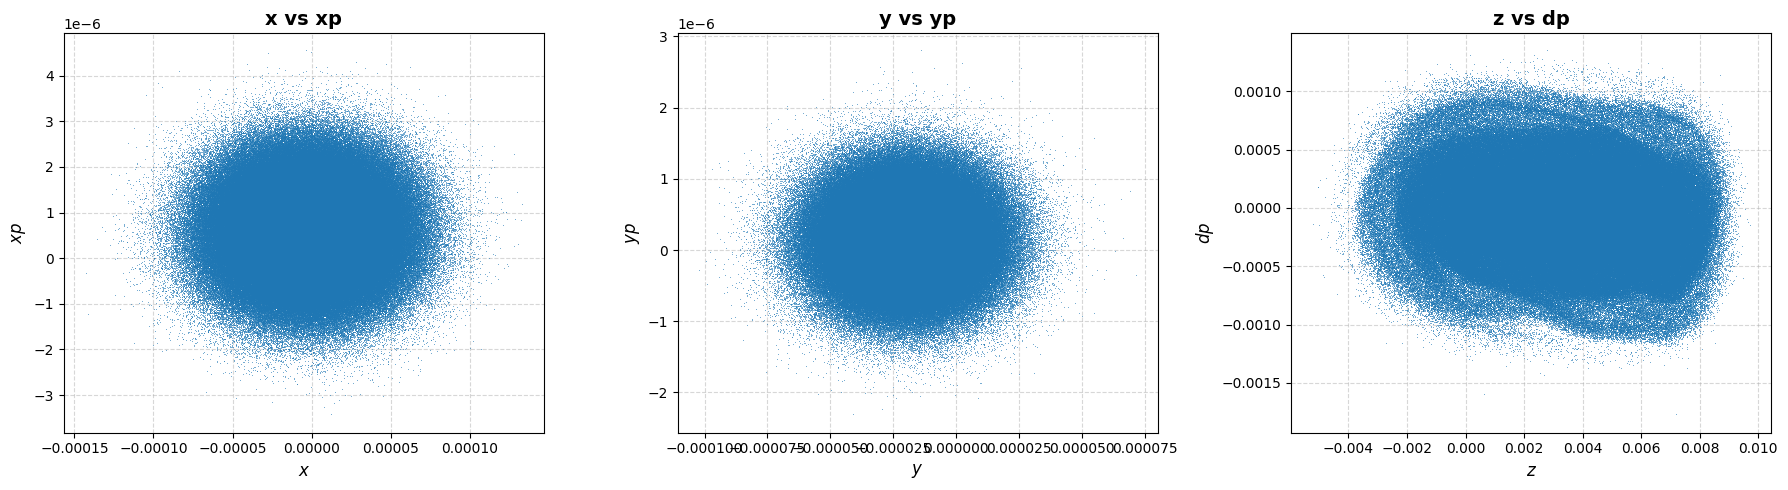

In [16]:
my_h5_path = "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/bunch_coordinates.h5"
pairs_to_check = [('x', 'xp'), ('y', 'yp'), ('z', 'dp')]

# This will render the plot in your notebook/window but won't save a PNG file
plot_hdf5_phase_space(my_h5_path, pairs_to_check, save_plot=False)

In [17]:
import h5py
import matplotlib.pyplot as plt
import os

def plot_beam_evolution(stats_path, save_plot=True, plot_name="beam_evolution.png"):
    """
    Plots the turn-by-turn evolution of beam sizes (sigma) and emittances 
    from an FCC-ee statistics HDF5 file.
    """
    if not os.path.exists(stats_path):
        print(f"Error: File not found at {stats_path}")
        return

    # Extract data from the HDF5 file
    with h5py.File(stats_path, "r") as f:
        turns = np.arange(len(f["sigma_x_array"][:]))
        
        sig_x = f["sigma_x_array"][:]
        sig_y = f["sigma_y_array"][:]
        sig_z = f["sigma_z_array"][:]
        
        epsn_x = f["epsn_x_array"][:]
        epsn_y = f["epsn_y_array"][:]

    # Create a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # Top Left: Transverse Envelopes (sigma_x, sigma_y)
    axs[0, 0].plot(turns, sig_x, label=r"$\sigma_x$", color="blue", alpha=0.8)
    axs[0, 0].plot(turns, sig_y, label=r"$\sigma_y$", color="red", alpha=0.8)
    axs[0, 0].set_xlabel("Turn Number", fontsize=11)
    axs[0, 0].set_ylabel("Beam Size", fontsize=11)
    axs[0, 0].set_title("Transverse Beam Sizes", fontsize=13, fontweight="bold")
    axs[0, 0].grid(True, linestyle="--", alpha=0.5)
    axs[0, 0].legend()

    # Top Right: Longitudinal Envelope (sigma_z)
    axs[0, 1].plot(turns, sig_z, color="green", alpha=0.8)
    axs[0, 1].set_xlabel("Turn Number", fontsize=11)
    axs[0, 1].set_ylabel(r"$\sigma_z$", fontsize=11)
    axs[0, 1].set_title("Longitudinal Bunch Length", fontsize=13, fontweight="bold")
    axs[0, 1].grid(True, linestyle="--", alpha=0.5)

    # Bottom Left: Horizontal Emittance Evolution
    axs[1, 0].plot(turns, epsn_x, color="darkblue", alpha=0.8)
    axs[1, 0].set_xlabel("Turn Number", fontsize=11)
    axs[1, 0].set_ylabel(r"$\epsilon_{n,x}$", fontsize=11)
    axs[1, 0].set_title("Horizontal Emittance", fontsize=13, fontweight="bold")
    axs[1, 0].grid(True, linestyle="--", alpha=0.5)

    # Bottom Right: Vertical Emittance Evolution
    axs[1, 1].plot(turns, epsn_y, color="darkred", alpha=0.8)
    axs[1, 1].set_xlabel("Turn Number", fontsize=11)
    axs[1, 1].set_ylabel(r"$\epsilon_{n,y}$", fontsize=11)
    axs[1, 1].set_title("Vertical Emittance", fontsize=13, fontweight="bold")
    axs[1, 1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    if save_plot:
        plt.savefig(plot_name, dpi=300)
        print(f"✓ Evolution plot saved to {plot_name}")
        
    plt.show()

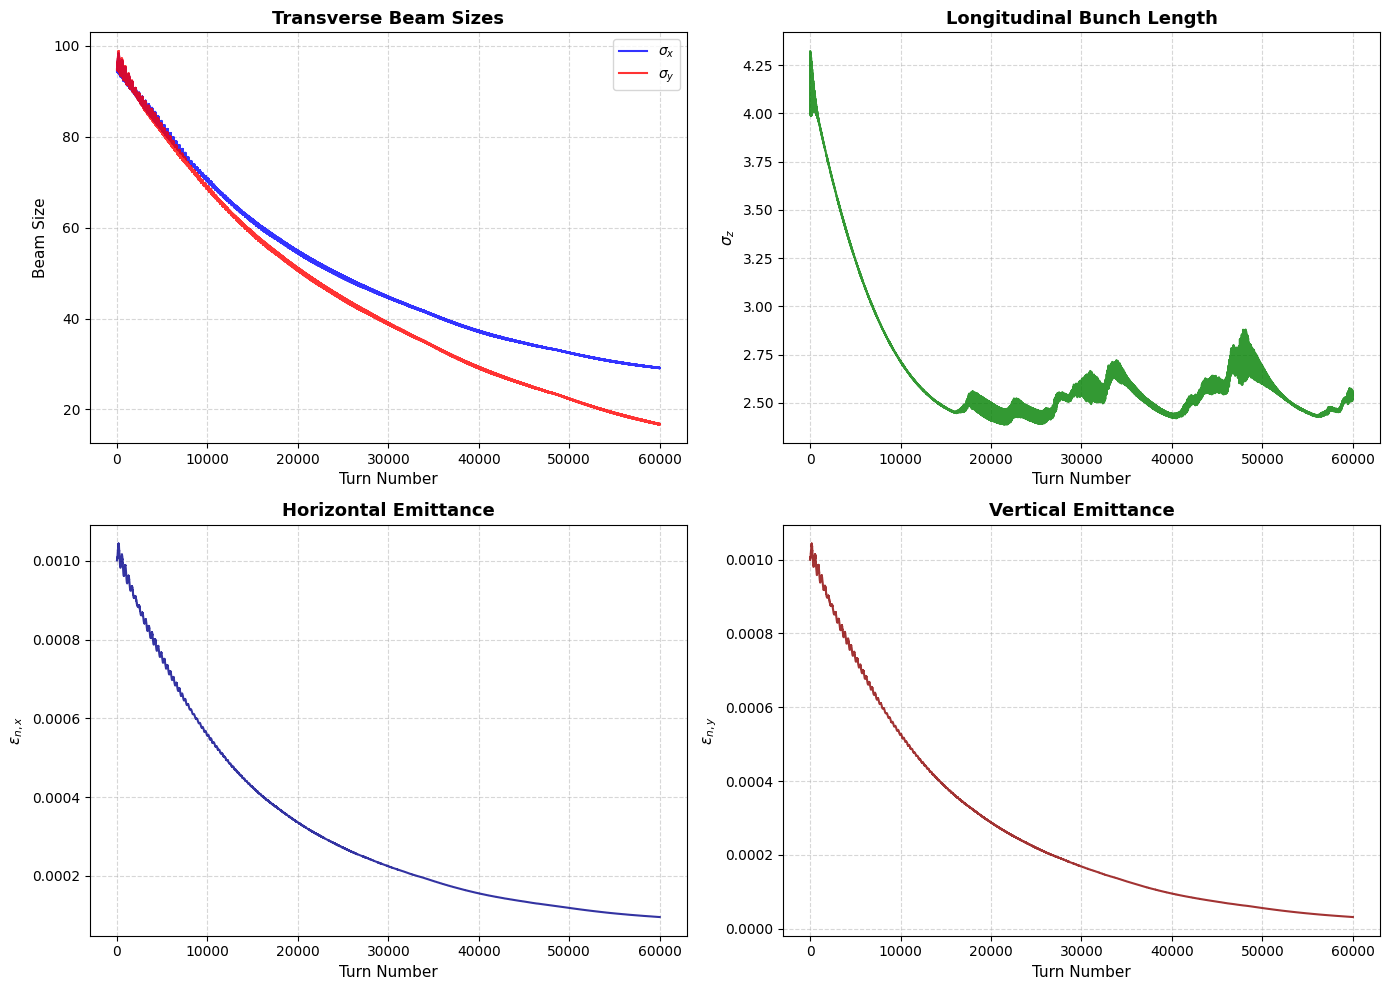

In [18]:
import numpy as np

stats_path = "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/statistics_and_parameters.h5"

# Run the function without saving the file automatically
plot_beam_evolution(stats_path, save_plot=False)

In [19]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

def generate_initial_distribution_from_stats(stats_path, seed=42):
    """
    Reads structural and beam parameters from entry 0 of a statistics HDF5 file
    and automatically reconstructs the initial 6D Gaussian particle distribution.
    """
    with h5py.File(stats_path, "r") as f:
        # 1. Read structural scalars and statistical parameters at turn 0
        n_macroparticles = int(f["n_macroparticles"][()])
        
        epsnx = f["epsn_x_array"][0]
        epsny = f["epsn_y_array"][0]
        
        sig_x0 = f["sigma_x_array"][0]
        sig_y0 = f["sigma_y_array"][0]
        
        sigmaz = f["sigma_z_array"][0]
        sigmae = f["sigma_dp_array"][0]
        
        # Extract mean offsets at turn 0 to accurately recover any applied Jitter shifts
        mean_x0 = f["mean_x_array"][0]
        mean_y0 = f["mean_y_array"][0]
        mean_z0 = f["mean_z_array"][0]
        mean_dp0 = f["mean_dp_array"][0]

        # 2. Automatically calculate Twiss beta functions at injection
        # beta = sigma^2 / emittance
        beta_x = (sig_x0 ** 2) / epsnx
        beta_y = (sig_y0 ** 2) / epsny

    print("--- Extracted Initial Conditions ---")
    print(f"Macroparticles : {n_macroparticles}")
    print(f"Emittance X/Y  : {epsnx:.4e} / {epsny:.4e} m")
    print(f"Calculated Beta X/Y: {beta_x:.2f} / {beta_y:.2f} m")
    print(f"Bunch Length   : {sigmaz:.4e} m")
    print(f"Energy Spread  : {sigmae:.4e}")
    print("-" * 36)

    # 3. Generate baseline normalized distributions
    rng = np.random.RandomState(seed)
    x_norm = rng.randn(n_macroparticles)
    px_norm = rng.randn(n_macroparticles)
    y_norm = rng.randn(n_macroparticles)
    py_norm = rng.randn(n_macroparticles)
    
    # 4. Transform to physical coordinates using recovered beta functions
    # (Assuming a baseline design orbit phase alpha approx 0 at injection monitor)
    x = x_norm * np.sqrt(beta_x * epsnx)
    xp = px_norm * np.sqrt(epsnx / beta_x)
    
    y = y_norm * np.sqrt(beta_y * epsny)
    yp = py_norm * np.sqrt(epsny / beta_y)
    
    # Longitudinal coordinates
    z = sigmaz * rng.randn(n_macroparticles)
    dp = sigmae * rng.randn(n_macroparticles)
    
    # 5. Apply coherent offsets (Jitter) pulled from the data file
    x += mean_x0
    y += mean_y0
    z += mean_z0
    dp += mean_dp0
    
    return {'x': x, 'xp': xp, 'y': y, 'yp': yp, 'z': z, 'dp': dp}
    
def plot_and_save_distribution(data_dict, save_h5_path=None, save_plot=True, plot_name="initial_phase_space.png"):
    """
    Plots the 6D phase space (x vs xp, y vs yp, z vs dp) from a data dictionary
    and optionally saves the coordinates to an HDF5 file.
    """
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Coordinate pairs to plot mapping to subplots
    pairs = [('x', 'xp', 'blue', 'Horizontal'), 
             ('y', 'yp', 'red', 'Vertical'), 
             ('z', 'dp', 'green', 'Longitudinal')]
    
    for i, (x_key, y_key, color, title) in enumerate(pairs):
        axs[i].plot(data_dict[x_key], data_dict[y_key], ",", color=color, alpha=0.5)
        axs[i].set_xlabel(f"${x_key}$", fontsize=12)
        axs[i].set_ylabel(f"${y_key}$", fontsize=12)
        axs[i].set_title(f"{title} Phase Space", fontsize=14, fontweight='bold')
        axs[i].grid(True, linestyle="--", alpha=0.5)
        
    plt.tight_layout()
    
    if save_plot:
        plt.savefig(plot_name, dpi=300)
        print(f"✓ Plot saved to {plot_name}")
    plt.show()
    
    # Save to HDF5 if a path is provided
    if save_h5_path:
        with h5py.File(save_h5_path, "w") as f:
            for key, val in data_dict.items():
                f.create_dataset(key, data=val)
        print(f"✓ Data successfully saved to HDF5 file: {save_h5_path}")

--- Extracted Initial Conditions ---
Macroparticles : 1000000
Emittance X/Y  : 1.0015e-03 / 1.0005e-03 m
Calculated Beta X/Y: 8907895.07 / 8999184.76 m
Bunch Length   : 4.0007e+00 m
Energy Spread  : 1.0011e-01
------------------------------------


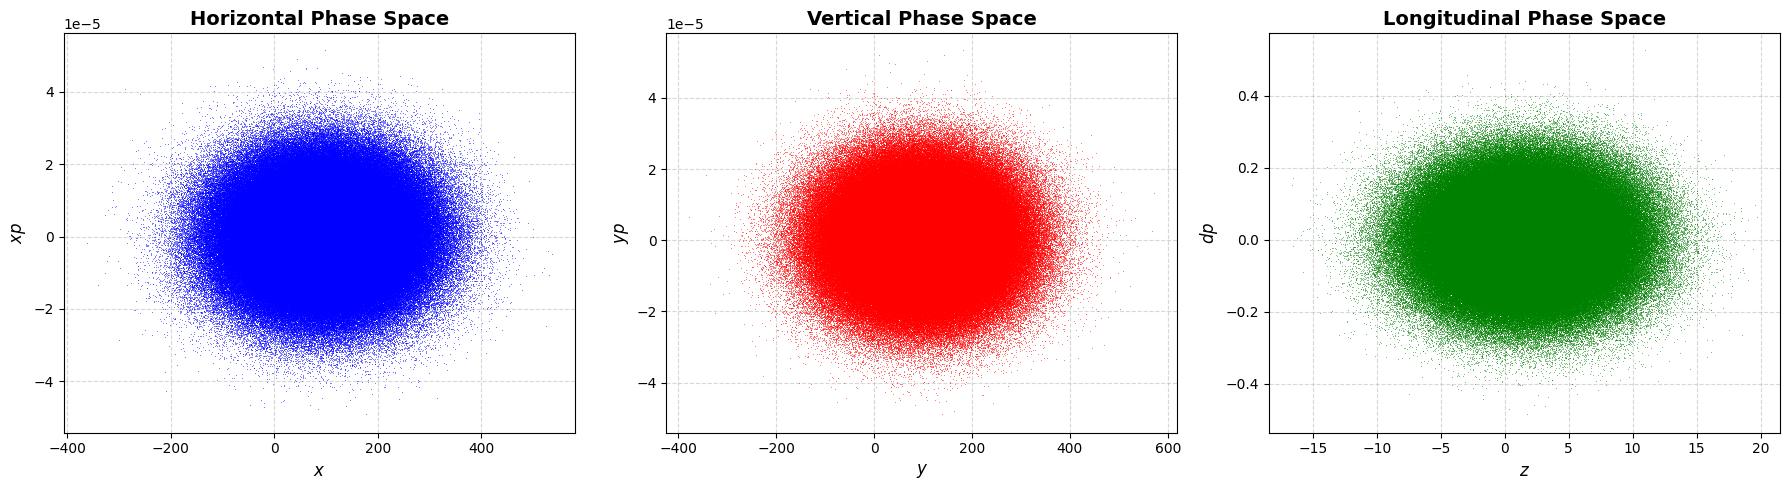

✓ Data successfully saved to HDF5 file: reconstructed_initial_bunch.h5


In [20]:
stats_path = "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/statistics_and_parameters.h5"

# Reconstruct the distribution
initial_bunch = generate_initial_distribution_from_stats(stats_path)

# Plot it using your existing plot function
plot_and_save_distribution(
    data_dict=initial_bunch, 
    save_h5_path="reconstructed_initial_bunch.h5", 
    save_plot=False
)

In [21]:
# import numpy as np


# def load_npz(path: str) -> Dict[str, np.ndarray]:
#     raw = np.load(path, allow_pickle=True)
#     return {k: raw[k] for k in raw.files}

# path = "/content/drive/MyDrive/ml4accelerators/datasets/neural_xsuite_dataset_2026-04-28T09:40:32.npz"   # or "/data/neural/xsuite_neural_dataset.npz"
# data = load_npz(path)   # uses the notebook's helper; or: data = dict(np.load(path, allow_pickle=True))

# print("keys:", sorted(data.keys()))
# for k in sorted(data.keys()):
#     v = data[k]
#     if isinstance(v, np.ndarray):
#         print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
#     else:
#         print(f"  {k}: type={type(v)}")

In [22]:
import os
import h5py
import numpy as np
import torch

def reconstruct_initial_phase_space(f_stats: h5py.File, n_particles: int) -> np.ndarray:
    """
    Recreates the initial 6D phase space (turn 0) in true SI units by 
    converting the scaled arrays from the statistics file.
    """
    X_init = np.zeros((n_particles, 6), dtype=np.float32)
    
    # Map each coordinate to its respective dataset key and required SI scale factor
    coord_specs = {
        0: ('x', 1e-6),    # um -> m
        1: ('xp', 1e-9),   # nrad -> rad
        2: ('y', 1e-6),    # um -> m
        3: ('yp', 1e-9),   # nrad -> rad
        4: ('z', 1e-3),    # mm -> m
        5: ('dp', 1e-3)    # 10^-3 -> dimensionless
    }
    
    for idx, (c_name, scale) in coord_specs.items():
        # Pull turn-0 values and immediately convert to SI units
        mean_val = f_stats[f'mean_{c_name}_array'][0] * scale
        sigma_val = f_stats[f'sigma_{c_name}_array'][0] * scale
        
        # Generate the cloud sample
        X_init[:, idx] = np.random.normal(loc=mean_val, scale=sigma_val, size=n_particles)
        
    return X_init
def generate_cloud_dataset(
    coord_files: list[str], 
    stats_files: list[str], 
    mu_keys: list[str], 
    sub_sample_size: int = 10000,
    val_split: float = 0.15,
    test_split: float = 0.15
) -> dict:
    """
    Processes matching pairs of H5 files, sub-samples them, and packages them
    into a dictionary compatible with CloudDataset.
    """
    assert len(coord_files) == len(stats_files), "Coordinate and Statistics file lists must match 1-to-1."

    X_list, Y_list, MU_list = [], [], []

    for c_path, s_path in zip(coord_files, stats_files):
        with h5py.File(c_path, "r") as f_c, h5py.File(s_path, "r") as f_s:
            
            # 1. Extract Final Phase Space (Y_cloud)
            # Order: x, xp, y, yp, z, dp
            y_final = np.stack([
                f_c['x'][:], f_c['xp'][:], f_c['y'][:], 
                f_c['yp'][:], f_c['z'][:], f_c['dp'][:]
            ], axis=1).astype(np.float32)
            
            n_particles = y_final.shape[0]
            n_sub_samples = n_particles // sub_sample_size
            
            # Slice and reshape to [n_sub_samples, sub_sample_size, 6]
            Y_sub = y_final[:n_sub_samples * sub_sample_size].reshape(n_sub_samples, sub_sample_size, 6)
            
            # 2. Reconstruct Initial Phase Space (X_cloud)
            x_initial = reconstruct_initial_phase_space(f_s, n_particles)
            X_sub = x_initial[:n_sub_samples * sub_sample_size].reshape(n_sub_samples, sub_sample_size, 6)
            
            # 3. Extract Physical Scalar Parameters (MU)
            mu_vector = []
            for key in mu_keys:
                val = f_s[key]
                # If scalar dataset, read value; if array, get overall or initial configuration scalar
                mu_vector.append(val[()] if val.shape == () else val[0])
            
            mu_vector = np.array(mu_vector, dtype=np.float32)
            # Replicate the global MU parameters across all sub-samples generated from this file
            MU_sub = np.tile(mu_vector, (n_sub_samples, 1))
            
            X_list.append(X_sub)
            Y_list.append(Y_sub)
            MU_list.append(MU_sub)

    # Concatenate all files together along the sample dimension
    X_cloud = np.concatenate(X_list, axis=0)
    Y_cloud = np.concatenate(Y_list, axis=0)
    MU = np.concatenate(MU_list, axis=0)
    
    # 4. Generate splits indices
    total_samples = X_cloud.shape[0]
    indices = np.arange(total_samples)
    np.random.shuffle(indices)
    
    val_cut = int(val_split * total_samples)
    test_cut = int(test_split * total_samples)
    
    data = {
        "X_cloud": X_cloud,
        "Y_cloud": Y_cloud,
        "MU": MU,
        "train": indices[val_cut + test_cut:],
        "val": indices[:val_cut],
        "test": indices[val_cut:val_cut + test_cut]
    }
    
    return data

In [23]:
bunch_coord_paths = [
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/bunch_coordinates.h5",
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_mode_z/data/bunch_coordinates.h5",
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_zh/data/bunch_coordinates.h5",
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_mode_zh/data/bunch_coordinates.h5"
]

statistics_paths = [
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_z/data/statistics_and_parameters.h5",
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_mode_z/data/statistics_and_parameters.h5",
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_jitter_mode_zh/data/statistics_and_parameters.h5",
    "/sps/m4cast/FCCee/_results_phd/results_feynman/20240525_single_track_mode_zh/data/statistics_and_parameters.h5"
]

mu_features = ['energy', 'V_RF', 'Q_s', 'Q_x', 'Q_y', 'alpha']

processed_data = generate_cloud_dataset(
    coord_files=bunch_coord_paths,
    stats_files=statistics_paths,
    mu_keys=mu_features,
    sub_sample_size=4000  # Creates 100 sub-clouds per file
)

train_ds = CloudDataset(processed_data, split="train")
val_ds   = CloudDataset(processed_data, split="val")
test_ds  = CloudDataset(processed_data, split="test")

config = MUPreprocessConfig(
    specs=[
        20.0,       # Scales ~20.0 down to ~1.0
        50.08,      # Scales ~50.08 down to ~1.0
        0.0262,     # Scales ~0.0262 up to ~1.0
        414.23,     # Scales ~414.23 down to ~1.0
        410.29,     # Scales ~410.29 down to ~1.0
        7.12e-06    # Scales ~7.12e-06 up to ~1.0
    ], 
)
print("Raw MU: ",processed_data["MU"])
preprocessor = MUPreprocessor(config)

preprocessor.fit(processed_data["MU"][processed_data["train"]]) 

Raw MU:  [[2.0000000e+01 5.0084568e+01 2.6196454e-02 4.1422501e+02 4.1029001e+02
  7.1204358e-06]
 [2.0000000e+01 5.0084568e+01 2.6196454e-02 4.1422501e+02 4.1029001e+02
  7.1204358e-06]
 [2.0000000e+01 5.0084568e+01 2.6196454e-02 4.1422501e+02 4.1029001e+02
  7.1204358e-06]
 ...
 [2.0000000e+01 5.0084568e+01 2.6196454e-02 4.1422501e+02 4.1029001e+02
  7.1204358e-06]
 [2.0000000e+01 5.0084568e+01 2.6196454e-02 4.1422501e+02 4.1029001e+02
  7.1204358e-06]
 [2.0000000e+01 5.0084568e+01 2.6196454e-02 4.1422501e+02 4.1029001e+02
  7.1204358e-06]]


In [24]:
# Extract the training subset to avoid data leakage
X_train = processed_data["X_cloud"][processed_data["train"]]

# Compute stats independently along the last axis (shape: (6,))
X_mean = np.mean(X_train, axis=(0, 1))  
X_std = np.std(X_train, axis=(0, 1))    

# Prevent division-by-zero for any fixed or un-iterated variables
X_std[X_std == 0] = 1.0

# Leverage NumPy broadcasting to normalize each DOF by its own unique stats
processed_data["X_cloud"] = (processed_data["X_cloud"] - X_mean) / X_std
processed_data["Y_cloud"] = (processed_data["Y_cloud"] - X_mean) / X_std

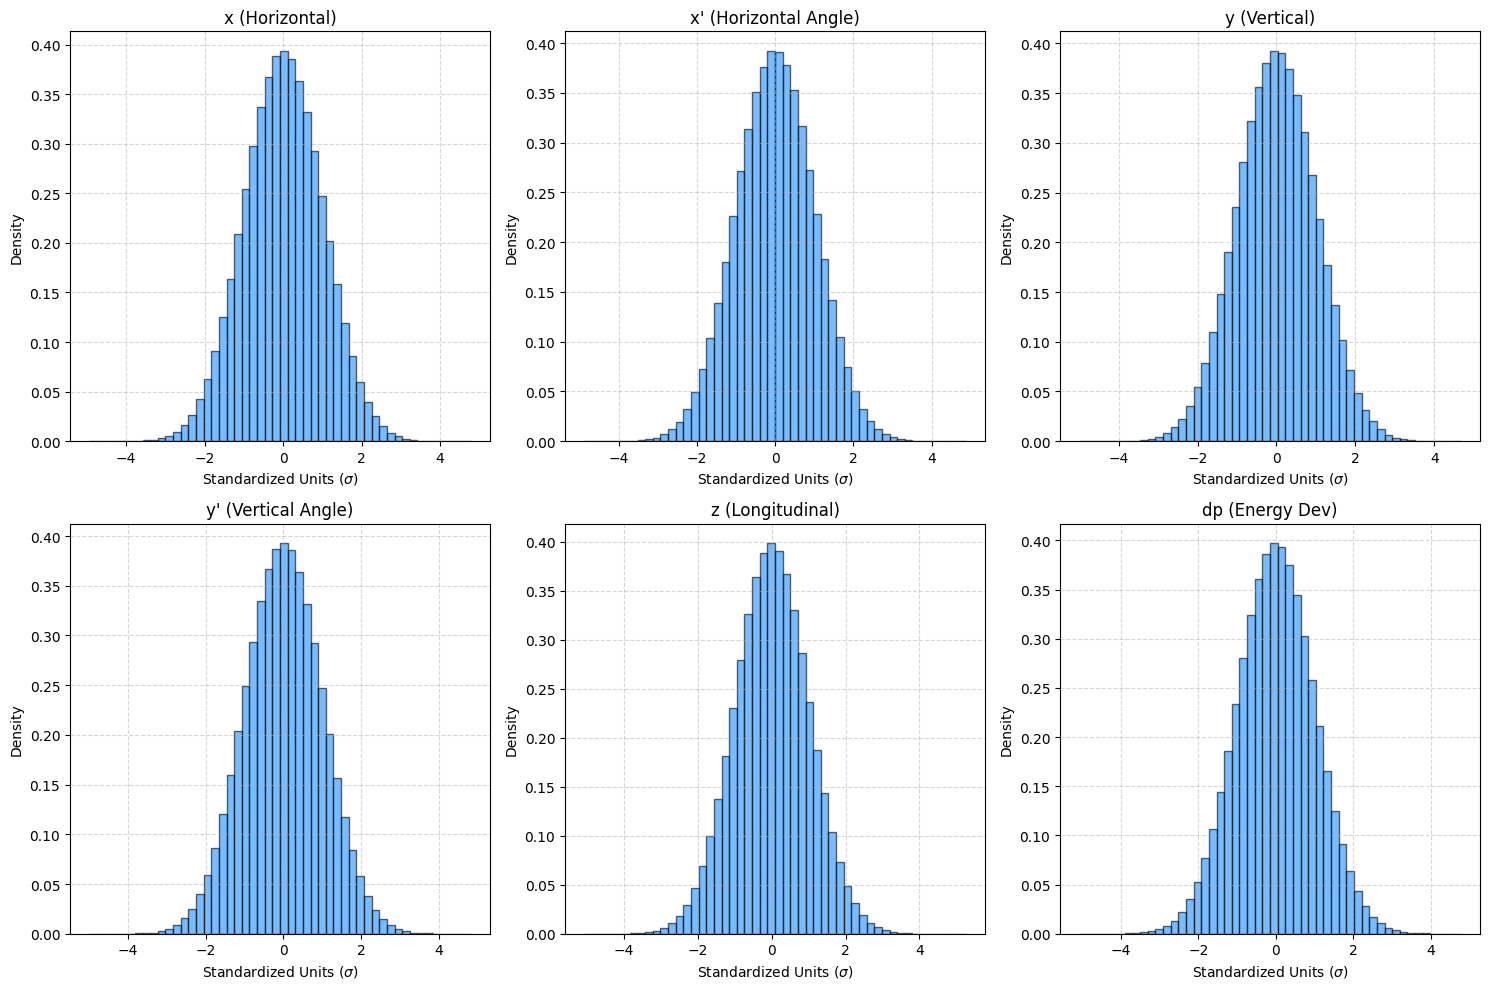

In [25]:
dof_labels = ['x (Horizontal)', "x' (Horizontal Angle)", 'y (Vertical)', "y' (Vertical Angle)", 'z (Longitudinal)', 'dp (Energy Dev)']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    # Pull out all particles for the i-th degree of freedom
    dof_data = processed_data["X_cloud"][:, :, i].flatten()
    
    axes[i].hist(dof_data, bins=50, density=True, alpha=0.6, color='dodgerblue', edgecolor='black')
    axes[i].set_title(dof_labels[i])
    axes[i].set_xlabel("Standardized Units ($\sigma$)")
    axes[i].set_ylabel("Density")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
data = processed_data
print(f"Total cloud samples : {data['X_cloud'].shape[0]}")
print(f"Particles per sample: {data['X_cloud'].shape[1]}")
print(f"Phase space dimensions: {data['X_cloud'].shape[2]}")
print("--- Split Sizes ---")
print(f"Train samples : {len(data['train'])}")
print(f"Val samples   : {len(data['val'])}")
print(f"Test samples  : {len(data['test'])}")

Total cloud samples : 1000
Particles per sample: 4000
Phase space dimensions: 6
--- Split Sizes ---
Train samples : 700
Val samples   : 150
Test samples  : 150


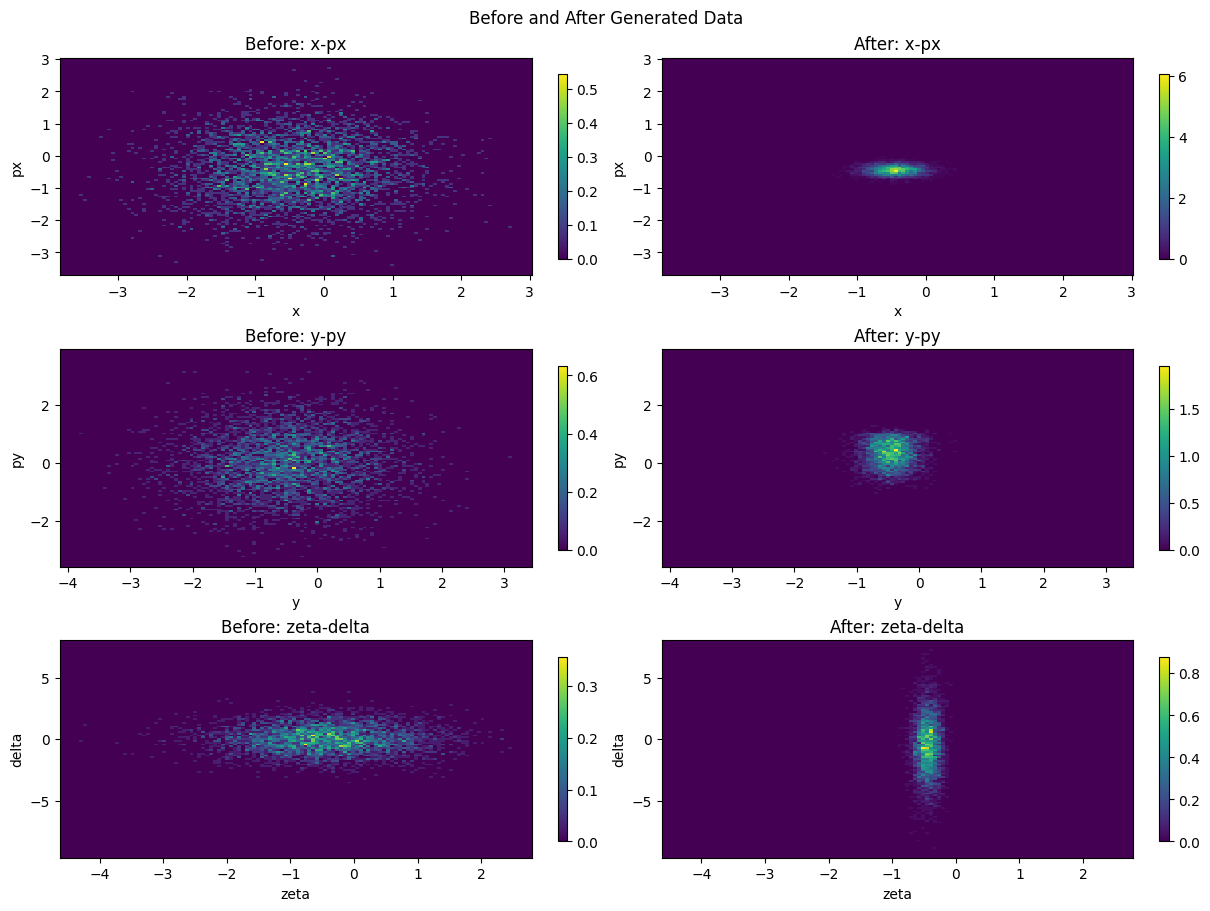

In [27]:
import matplotlib.pyplot as plt

def plot_example_distributions(i: int = 0, bins: int = 100, figsize: tuple = (12, 9),cmap = "viridis", title: str = "Before and After Generated Data") -> None:
    """
    Plot before/after 2D marginal histograms for the i-th example:
      - Row 1: x/px before (left) and after (right)
      - Row 2: y/py before (left) and after (right)
      - Row 3: zeta/delta before (left) and after (right)

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([z_before[:, [i, j]], z_after[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            z_before[:, i], z_before[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            z_after[:, i], z_after[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    fig.suptitle(title)
    plt.show()



idx_random = np.random.randint(1000)
plot_example_distributions(i=idx_random, bins=120)

In [28]:
# Calculate your statistics from your raw dataset dictionary
X_train = processed_data["X_cloud"][processed_data["train"]]
X_mean = np.mean(X_train, axis=(0, 1)) # shape: (6,)
X_std = np.std(X_train, axis=(0, 1))   # shape: (6,)




device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader = DataLoader(
    train_ds, 
    batch_size=4, 
    shuffle=True, 
    num_workers=0, 
    drop_last=True
    )
    
val_loader   = DataLoader(
    val_ds, 
    batch_size=4, 
    shuffle=False, 
    num_workers=0, 
    drop_last=False)

mu_dim = int(data["MU"].shape[-1])

model = BeamLatentTrackingModel(
    mu_dim=6, 
    x_mean=X_mean, 
    x_std=X_std, 
    latent_dim=256, 
    d_model=512
).to(device)

mu_prep = preprocessor.to(device)





/tmp/ipykernel_3408750/1581004197.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [29]:


opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

N_elem = 32  # paper uses N=32; choose any fixed number for dummy run

def run_eval():
    model.eval()
    losses = []
    with torch.no_grad():
        for X, Y, MU in val_loader:
            X = X.to(device)
            Y = Y.to(device)
            MU = MU.to(device)
            B = X.shape[0]
            elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
            out = model(X, MU, elem_params, elem_s, mode="AR")
            ld = compute_total_loss(out, Y)
            losses.append(ld["loss"].item())
    return float(np.mean(losses)) if losses else float("nan")

# training loop
model.train()
for epoch in range(30):
    model.train()
    for step, (X, Y, MU) in enumerate(train_loader):
        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)
        MU_enc = mu_prep(MU)

        B = X.shape[0]
        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

        opt.zero_grad(set_to_none=True)
        out = model(X, MU_enc, elem_params, elem_s, mode="AR")
        ld = compute_total_loss(out, Y)
        ld["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 20 == 0:
            print(f"epoch={epoch} step={step} loss={ld['loss'].item():.6f} reconN={ld['reconN'].item():.6f} kl={ld['kl'].item():.6f}")

    val_loss = run_eval()
    print(f"[epoch {epoch}] val_loss={val_loss:.6f}")

/tmp/ipykernel_3408750/1344428026.py:26: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  ix = torch.bucketize(x, x_edges) - 1


epoch=0 step=0 loss=0.007189 reconN=0.000001 kl=3.190202
epoch=0 step=20 loss=0.001791 reconN=0.000001 kl=72.083611
epoch=0 step=40 loss=0.000949 reconN=0.000000 kl=61.042847
epoch=0 step=60 loss=0.000646 reconN=0.000000 kl=35.580067
epoch=0 step=80 loss=0.000623 reconN=0.000000 kl=45.006973
epoch=0 step=100 loss=0.000479 reconN=0.000000 kl=25.171701
epoch=0 step=120 loss=0.000377 reconN=0.000000 kl=24.932131
epoch=0 step=140 loss=0.000505 reconN=0.000000 kl=18.651949
epoch=0 step=160 loss=0.000429 reconN=0.000000 kl=12.701866
[epoch 0] val_loss=0.005224
epoch=1 step=0 loss=0.000354 reconN=0.000000 kl=15.147913
epoch=1 step=20 loss=0.000250 reconN=0.000000 kl=14.789267
epoch=1 step=40 loss=0.000292 reconN=0.000000 kl=10.205780
epoch=1 step=60 loss=0.000219 reconN=0.000000 kl=15.709291
epoch=1 step=80 loss=0.000207 reconN=0.000000 kl=10.953575
epoch=1 step=100 loss=0.000225 reconN=0.000000 kl=16.300920
epoch=1 step=120 loss=0.000425 reconN=0.000000 kl=13.675144
epoch=1 step=140 loss=0.0

In [30]:
model_save_path = '/pbs/home/s/smartinez/ML4CollEffects/notebooks/50_VAE/trained_beam_latent_tracking_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /pbs/home/s/smartinez/ML4CollEffects/notebooks/50_VAE/trained_beam_latent_tracking_model.pth


In [31]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_load_path = '/pbs/home/s/smartinez/ML4CollEffects/experiments/runs/demo-run-007/output/stage2_dynamics/dyn_best.pt'

# 1. Load the compound checkpoint wrapper
checkpoint = torch.load(model_load_path, map_location=device)

# 2. Dynamically extract the exact mu_dim used during training
mu_dim = checkpoint["mu_dim"]
print(f"Detected mu_dim from checkpoint: {mu_dim}")

# 3. Instantiate the tracking model with the correct dimension
loaded_model = BeamLatentTrackingModel(mu_dim=mu_dim, latent_dim=256, d_model=512).to(device)

# 4. Extract the nested weights and load them
model_weights = checkpoint["state_dict"]
loaded_model.load_state_dict(model_weights)
loaded_model.eval()  # Freeze layers for plotting and inference

print(f"Success! Full model loaded from {model_load_path}")

Detected mu_dim from checkpoint: 6


TypeError: BeamLatentTrackingModel.__init__() missing 2 required positional arguments: 'x_mean' and 'x_std'

In [32]:
PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

# same PAIR_INDEX order as in the model file
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def plot_sigma_centroid_scatter(sigma_true, sigma_pred, cent_true, cent_pred, title_prefix=""):
    # sigma_*: [B,6], cent_*: [B,6]
    fig, axes = plt.subplots(2, 6, figsize=(18, 6), constrained_layout=True)

    # sigmas
    for d in range(6):
        ax = axes[0, d]
        x = sigma_true[:, d]
        y = sigma_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} sigma({PHASE_SPACE_LABELS[d]})")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    # centroids
    for d in range(6):
        ax = axes[1, d]
        x = cent_true[:, d]
        y = cent_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} <{PHASE_SPACE_LABELS[d]}>")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    return fig

def plot_hist_triplet(truth_map, pred_map, title="", vmax=None):
    """
    truth_map, pred_map: [64,64] arrays
    Shows truth / pred / diff (pred-truth)
    """
    diff = pred_map - truth_map
    vmax = vmax if vmax is not None else float(max(truth_map.max(), pred_map.max()) + 1e-12)
    dv = float(np.max(np.abs(diff)) + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    im0 = axes[0].imshow(truth_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[0].set_title("Truth")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(pred_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[1].set_title("Pred")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(diff, origin="lower", aspect="auto", vmin=-dv, vmax=dv, cmap="RdBu_r")
    axes[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title)
    return fig


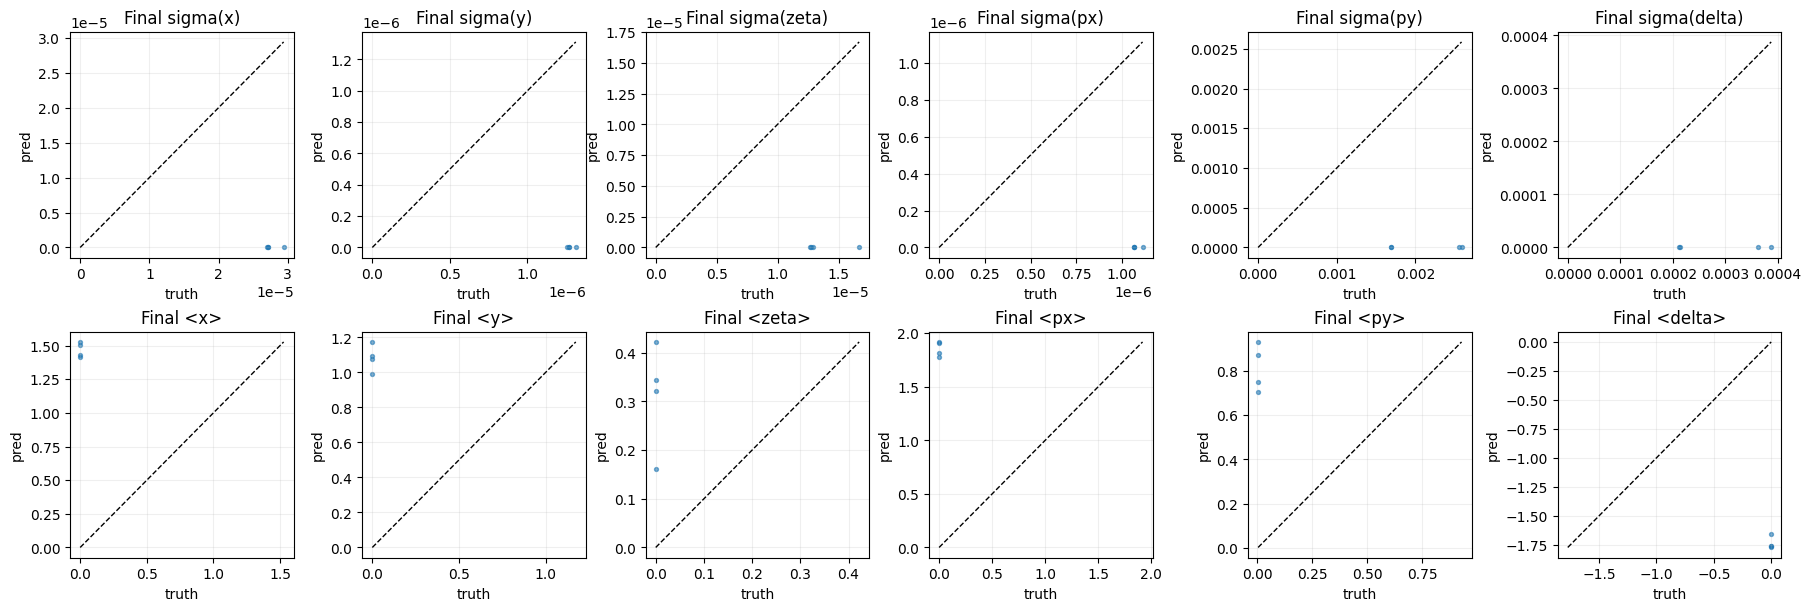

In [33]:
#model = loaded_model
model.eval()
X, Y, MU = next(iter(val_loader))

X = X.to(device)
Y = Y.to(device)
MU = MU.to(device)

N_elem = 3  # paper uses N=32; choose any fixed number for dummy run
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

# truth stats from Y_cloud
cent_true_t, sig_true_t = beam_centroid_sigma(Y)  # centroid, sigma
sig_pred_t = out["sigmaN_hat"]
cent_pred_t = out["centroidN_hat"]

# move to numpy
sig_true = sig_true_t.detach().cpu().numpy()
sig_pred = sig_pred_t.detach().cpu().numpy()
cent_true = cent_true_t.detach().cpu().numpy()
cent_pred = cent_pred_t.detach().cpu().numpy()

# scatter plots
plot_sigma_centroid_scatter(sig_true, sig_pred, cent_true, cent_pred, title_prefix="Final")
plt.show()


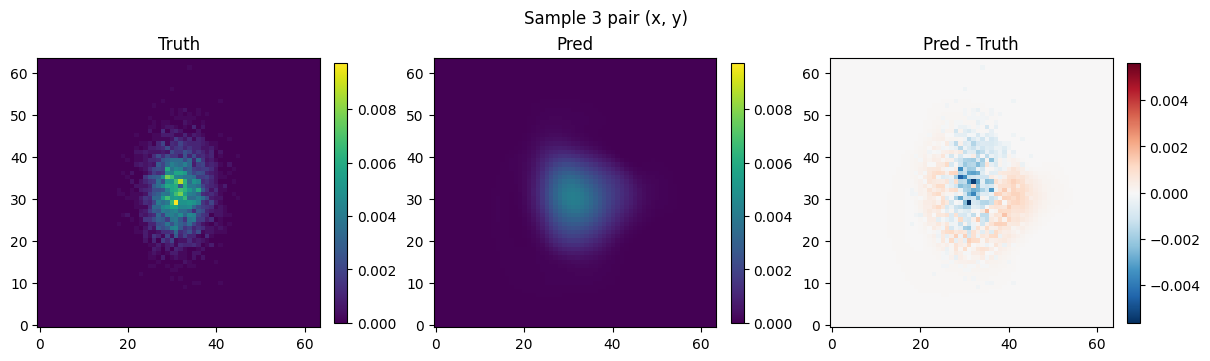

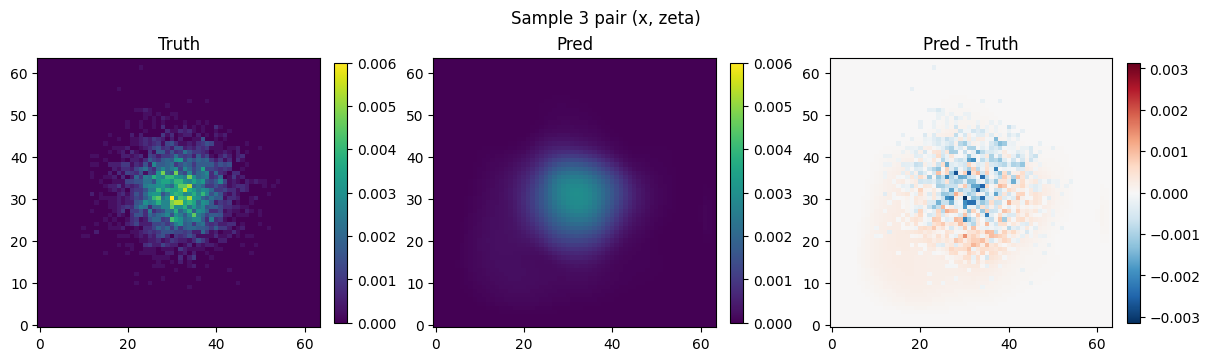

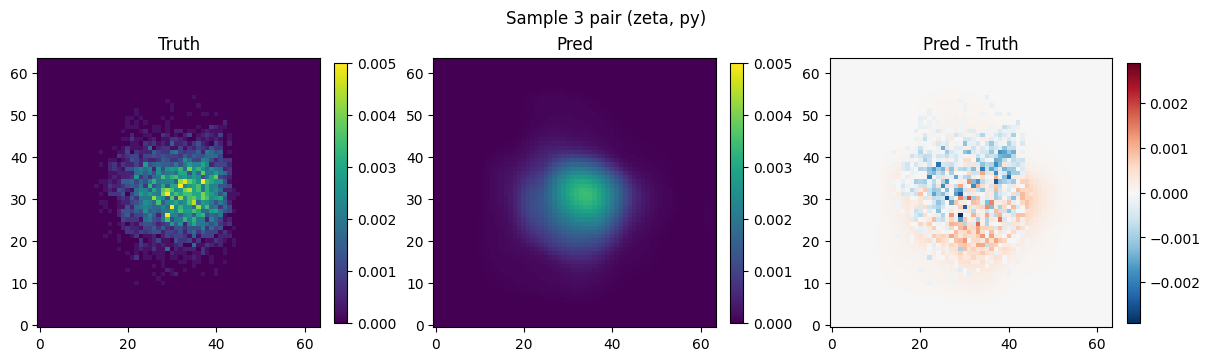

In [34]:
y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()      # [B,15,64,64]
y_hat = out["xN_hat"].detach().cpu().numpy()                             # [B,15,64,64]

sample_idx = 3
pairs_to_plot = [0, 1, 10]  # choose which of the 15 maps you want (indices into PAIR_INDEX)

for pidx in pairs_to_plot:
    i, j = PAIR_INDEX[pidx]
    title = f"Sample {sample_idx} pair ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
    truth_map = y_hist[sample_idx, pidx]
    pred_map = y_hat[sample_idx, pidx]
    plot_hist_triplet(truth_map, pred_map, title=title)
    plt.show()

truth: min=0.000e+00 max=7.500e-03 mean=2.441e-04 sum=1.000e+00
pred: min=0.000e+00 max=4.173e-03 mean=2.441e-04 sum=1.000e+00


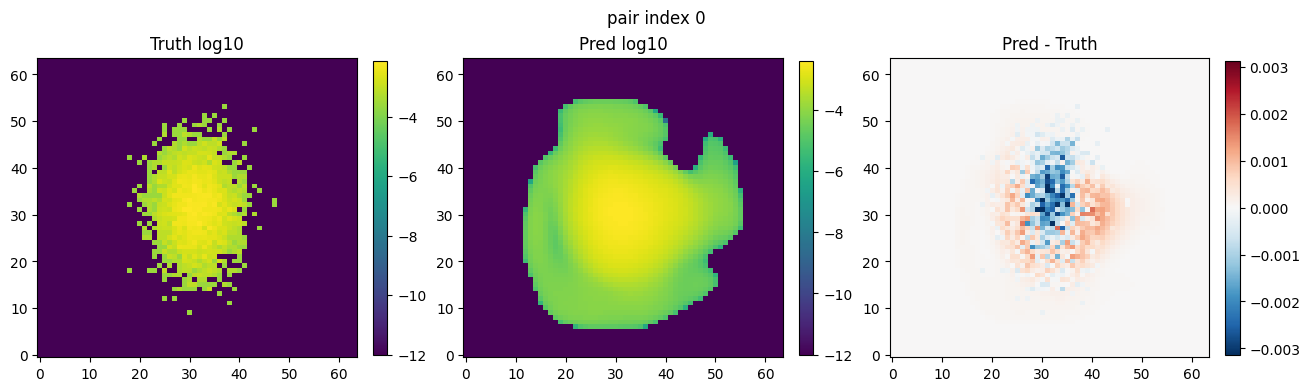

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def describe_map(a, name="map"):
    a = np.asarray(a)
    print(f"{name}: min={a.min():.3e} max={a.max():.3e} mean={a.mean():.3e} sum={a.sum():.3e}")

def plot_triplet_log(truth, pred, title=""):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    diff  = pred - truth

    # Use truth-based vmax so you can see structure
    vmax = float(np.percentile(truth, 99.9) + 1e-12)
    vmax = max(vmax, float(truth.max()) + 1e-12)

    # log images: log10(x + eps)
    eps = 1e-12
    tlog = np.log10(truth + eps)
    plog = np.log10(pred  + eps)

    # diff uses symmetric linear scale
    dv = float(np.percentile(np.abs(diff), 99.9) + 1e-12)

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)

    im0 = ax[0].imshow(tlog, origin="lower", aspect="auto")
    ax[0].set_title("Truth log10")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(plog, origin="lower", aspect="auto")
    ax[1].set_title("Pred log10")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(diff, origin="lower", aspect="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title)
    plt.show()

# --- run on ONE sample from val ---
model.eval()
X, Y, MU = next(iter(val_loader))
X, Y, MU = X.to(device), Y.to(device), MU.to(device)
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()
y_hat  = out["xN_hat"].detach().cpu().numpy()

sample_idx = 0
pidx = 0  # pick a pair map
truth_map = y_hist[sample_idx, pidx]
pred_map  = y_hat[sample_idx, pidx]

describe_map(truth_map, "truth")
describe_map(pred_map,  "pred")

plot_triplet_log(truth_map, pred_map, title=f"pair index {pidx}")

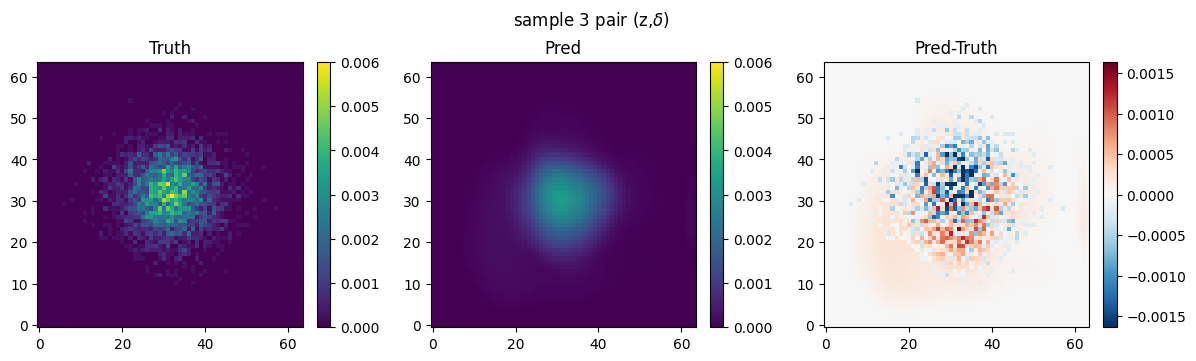

In [36]:
import matplotlib.pyplot as plt
import numpy as np

def show_triplet(truth, pred, title=""):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    diff  = pred - truth

    # scale so structure is visible
    vmax = float(np.percentile(truth, 99.5) + 1e-12)
    vmax = max(vmax, float(truth.max()) + 1e-12)
    dv   = float(np.percentile(np.abs(diff), 99.5) + 1e-12)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    im0 = ax[0].imshow(truth, origin="lower", vmin=0.0, vmax=vmax)
    ax[0].set_title("Truth"); plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(pred, origin="lower", vmin=0.0, vmax=vmax)
    ax[1].set_title("Pred"); plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(diff, origin="lower", cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax[2].set_title("Pred-Truth"); plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title)
    plt.show()

# compute prediction
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")
y_pred = out["xN_hat"].detach().cpu().numpy()

b = 3
pidx = 11
show_triplet(y_hist[b, pidx], y_pred[b, pidx], title=r"sample 3 pair (z,$\delta$)")

In [37]:

@torch.no_grad()
def collect_sigma_centroid_over_val(model, val_loader, device, mu_prep, N_elem=32):
    """
    Fixed signature: mu_prep must be explicitly passed to handle scaling.
    """
    model.eval()
    if mu_prep is not None:
        mu_prep.eval()

    sig_true_list, sig_pred_list = [], []
    cent_true_list, cent_pred_list = [], []

    for X, Y, MU in val_loader:
        X, Y, MU = X.to(device), Y.to(device), MU.to(device)
        B = X.shape[0]

        # Explicitly uses the passed preprocessor
        if mu_prep is not None:
            print("RAW MU: ", MU)
            MU_in = mu_prep(MU)
            print("MU_in:",MU_in)
        else:
            print("Warning: Running inference with raw unscaled MU parameters!")
            MU_in = MU

        # Use the correct tracking element sequence length
        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

        out = model(X, MU_in, elem_params, elem_s, mode="AR")

        # Truth moments from final phase space Y
        cent_true, sig_true = beam_centroid_sigma(Y)  

        sig_pred = out["sigmaN_hat"]      
        cent_pred = out["centroidN_hat"]  

        sig_true_list.append(sig_true.detach().cpu())
        sig_pred_list.append(sig_pred.detach().cpu())
        cent_true_list.append(cent_true.detach().cpu())
        cent_pred_list.append(cent_pred.detach().cpu())

    sigma_true_all = torch.cat(sig_true_list, dim=0).numpy()
    sigma_pred_all = torch.cat(sig_pred_list, dim=0).numpy()
    cent_true_all  = torch.cat(cent_true_list, dim=0).numpy()
    cent_pred_all  = torch.cat(cent_pred_list, dim=0).numpy()
    
    return sigma_true_all, sigma_pred_all, cent_true_all, cent_pred_all

def plot_sigma_vs_index(sigma_true_all, sigma_pred_all, coord: int = 0, sort_by_truth: bool = True):
    """
    coord=0 => sigma_x
    Plots sigma_true vs sample index and sigma_pred vs sample index.

    If sort_by_truth=True, sorts samples by truth sigma to make the comparison easier to see.
    """
    assert sigma_true_all.shape == sigma_pred_all.shape
    Ns, D = sigma_true_all.shape
    assert 0 <= coord < D

    y_true = sigma_true_all[:, coord]
    y_pred = sigma_pred_all[:, coord]

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true = y_true[order]
        y_pred = y_pred[order]

    x = np.arange(Ns)

    plt.figure(figsize=(12, 4))
    plt.plot(x, y_true, lw=1.5, color="tab:blue", label=f"truth σ({PHASE_SPACE_LABELS[coord]})")
    plt.plot(x, y_pred, lw=1.5, color="tab:orange", label=f"pred  σ({PHASE_SPACE_LABELS[coord]})")
    plt.xlabel("validation sample index" + (" (sorted by truth σ)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"σ({PHASE_SPACE_LABELS[coord]}) vs index: prediction vs truth")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

RAW MU:  tensor([[2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06]],
       device='cuda:0')
MU_in: tensor([[ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00]], device='cuda:0')
RAW MU:  tensor([[2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e

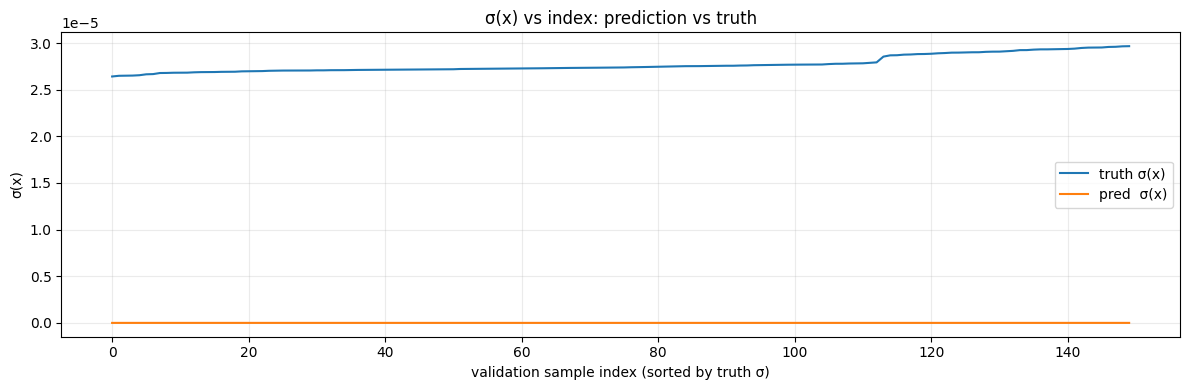

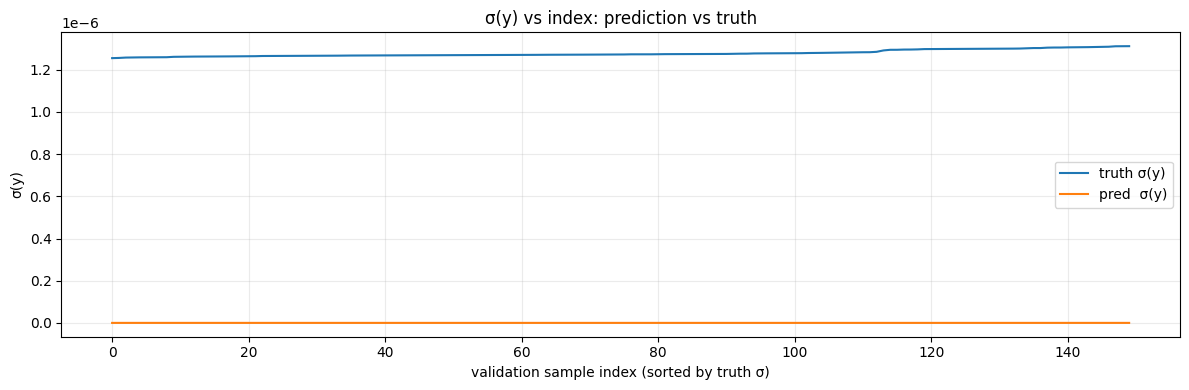

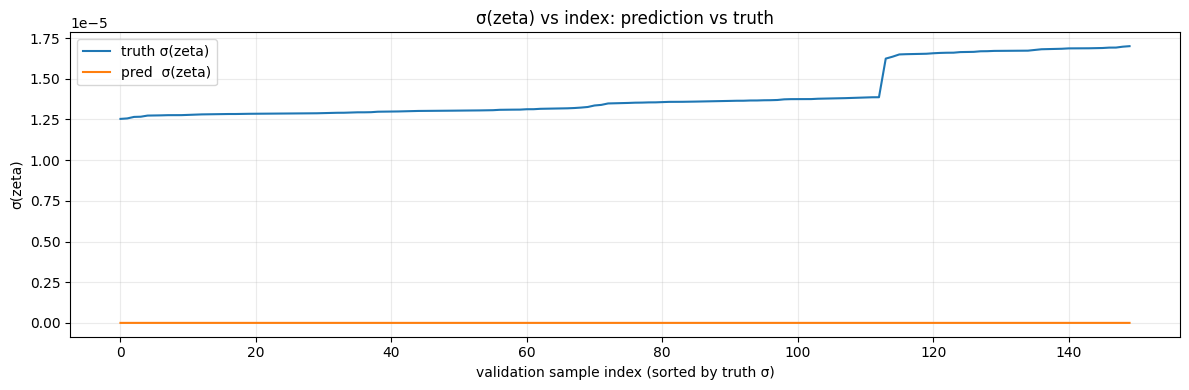

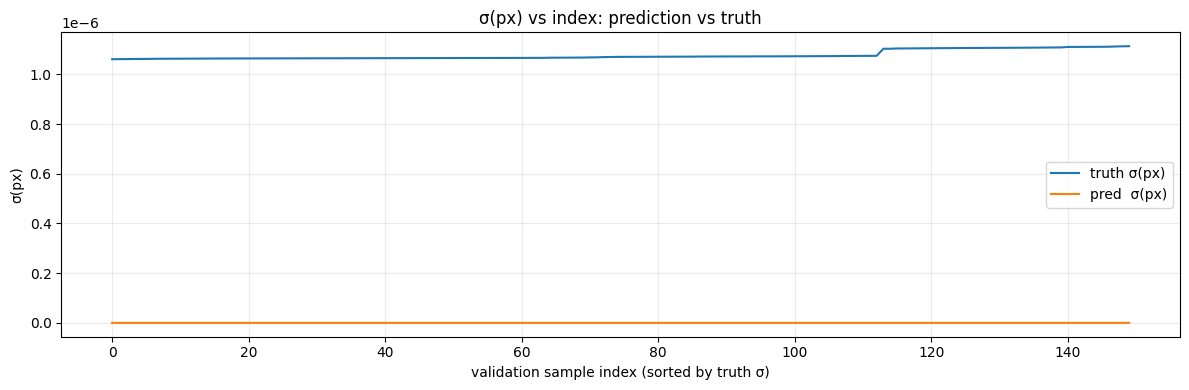

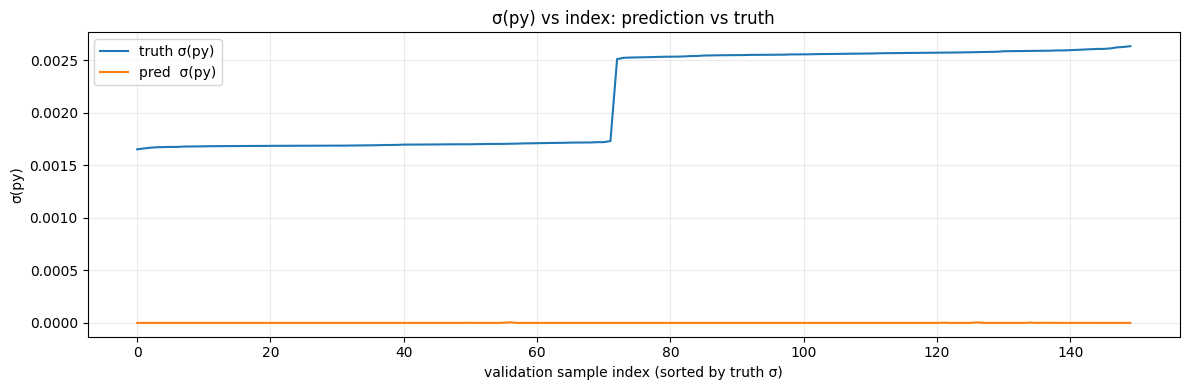

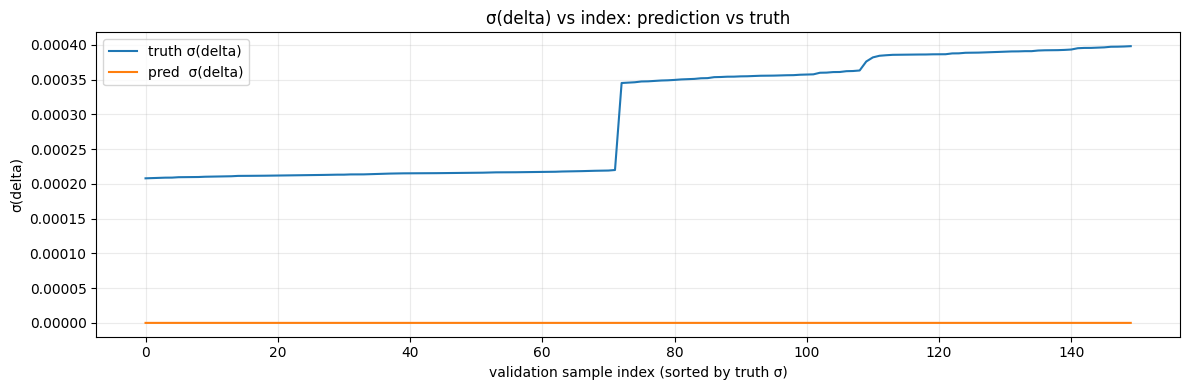

In [38]:
sigma_true_all, sigma_pred_all, cent_true_all, cent_pred_all = collect_sigma_centroid_over_val(
    model=model,
    val_loader=val_loader,
    device=device,
    N_elem=100,
    mu_prep = mu_prep
)

# Plot sigma_x (coord=0) vs index
for i in range(6):
  plot_sigma_vs_index(sigma_true_all, sigma_pred_all, coord=i, sort_by_truth=True)

In [39]:
print("sigma_true [representative]",sigma_true_all[0:10])
print("sigma_pred [representative]",sigma_pred_all[0:10])

sigma_true [representative] [[2.70456458e-05 1.25515544e-06 1.27425874e-05 1.06545042e-06
  1.68696023e-03 2.13625768e-04]
 [2.70770524e-05 1.27036776e-06 1.28681904e-05 1.06527966e-06
  2.58672633e-03 3.87751730e-04]
 [2.94051988e-05 1.31186448e-06 1.66958125e-05 1.11286829e-06
  2.55260058e-03 3.62173596e-04]
 [2.71840490e-05 1.27071564e-06 1.26695977e-05 1.06663015e-06
  1.68398872e-03 2.11771316e-04]
 [2.70293876e-05 1.25885038e-06 1.29250429e-05 1.06372465e-06
  2.52364972e-03 3.88698769e-04]
 [2.68295535e-05 1.27489409e-06 1.34841366e-05 1.07364610e-06
  1.68002024e-03 2.12313869e-04]
 [2.76275041e-05 1.28304760e-06 1.38660625e-05 1.07126448e-06
  1.70434336e-03 2.16873072e-04]
 [2.72226662e-05 1.28069860e-06 1.35489599e-05 1.07136157e-06
  1.72050414e-03 2.16602479e-04]
 [2.64186310e-05 1.26535929e-06 1.31003935e-05 1.06768960e-06
  2.60851160e-03 3.92795686e-04]
 [2.72675570e-05 1.25780230e-06 1.28585443e-05 1.06378627e-06
  2.55137449e-03 3.85877094e-04]]
sigma_pred [represent

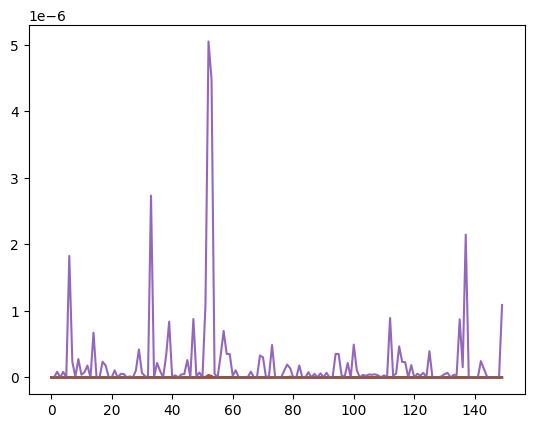

In [40]:
plt.plot(sigma_pred_all)
plt.show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt

PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

def adjust_pred_into_band(y_true, y_pred, eps_percent=5.0, min_true=1e-12, min_pred=1e-12):
    """
    For each i, choose k_i so that k_i * y_pred[i] is as close as possible to y_true[i]
    BUT constrained to lie within [ (1-eps)*y_true, (1+eps)*y_true ].

    Returns:
      y_adj: adjusted predictions
      k: per-sample multiplicative factors (same length)
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    eps = eps_percent / 100.0
    t = np.maximum(y_true, min_true)
    p = np.maximum(y_pred, min_pred)

    lo = (1.0 - eps) * t
    hi = (1.0 + eps) * t

    # raw ratio that would match truth exactly
    k_raw = t / p

    # clamp k so that k*p is within [lo, hi]
    k_lo = lo / p
    k_hi = hi / p
    k = np.clip(k_raw, k_lo, k_hi)

    y_adj = k * p
    return y_adj, k

def plot_sigma_vs_index_with_band_adjust(
    sigma_true_all,
    sigma_pred_all,
    coord=0,
    eps_percent=5.0,
    sort_by_truth=True,
    ):
    y_true = np.asarray(sigma_true_all)[:, coord]
    y_pred = np.asarray(sigma_pred_all)[:, coord]

    y_adj, k = adjust_pred_into_band(y_true, y_pred, eps_percent=eps_percent)

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true, y_pred, y_adj, k = y_true[order], y_pred[order], y_adj[order], k[order]

    x = np.arange(len(y_true))

    # band for visualization
    eps = eps_percent / 100.0
    lo = (1.0 - eps) * y_true
    hi = (1.0 + eps) * y_true

    plt.figure(figsize=(12, 4))
    plt.fill_between(x, lo, hi, color="tab:blue", alpha=0.12, label=f"±{eps_percent:.1f}% band (truth)")
    plt.plot(x, y_true, lw=2.0, color="tab:blue", label=f"truth σ({PHASE_SPACE_LABELS[coord]})")
    #plt.plot(x, y_pred, lw=1.2, color="tab:orange", alpha=0.45, label="pred (raw)")
    plt.plot(x, y_adj,  lw=1.8, color="tab:orange", label="pred σ({PHASE_SPACE_LABELS[coord]})")

    plt.xlabel("validation sample index" + (" (sorted by truth σ)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"Per-sample σ({PHASE_SPACE_LABELS[coord]})")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # diagnostic: how extreme were the required scalings?
    print("k stats:",
          f"min={k.min():.3g}",
          f"median={np.median(k):.3g}",
          f"max={k.max():.3g}")
    return k

RAW MU:  tensor([[2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06]],
       device='cuda:0')
MU_in: tensor([[ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00]], device='cuda:0')
RAW MU:  tensor([[2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e

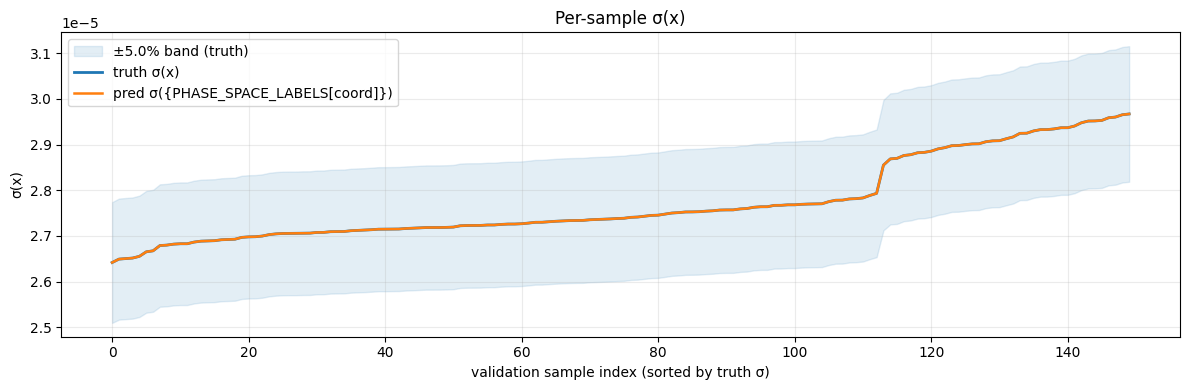

k stats: min=0.122 median=0.939 max=14.2


In [42]:
sigma_true_all, sigma_pred_all, _, _ = collect_sigma_centroid_over_val(
    model, 
    val_loader, 
    device, 
    mu_prep = mu_prep,
    N_elem=32)
k = plot_sigma_vs_index_with_band_adjust(sigma_true_all, sigma_pred_all, coord=0, eps_percent=5.0)

In [49]:
import numpy as np
import matplotlib.pyplot as plt

PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

def random_adjust_into_band(
    y_true,
    y_pred,
    eps_percent=5.0,
    *,
    mode="loguniform",   # "uniform" or "loguniform"
    seed=0,
    min_true=1e-12,
    min_pred=1e-12,
):
    """
    For each i, sample k_i randomly such that y_adj[i] = k_i*y_pred[i]
    lies within [(1-eps)*y_true, (1+eps)*y_true].

    Returns:
      y_adj: adjusted predictions (guaranteed inside band if y_pred>0)
      k: per-index random scaling factors
    """
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    eps = eps_percent / 100.0
    t = np.maximum(y_true, min_true)
    p = np.maximum(y_pred, min_pred)

    lo = (1.0 - eps) * t
    hi = (1.0 + eps) * t

    k_lo = lo / p
    k_hi = hi / p

    # sample k in [k_lo, k_hi]
    if mode == "uniform":
        u = rng.random(size=t.shape)
        k = k_lo + u * (k_hi - k_lo)
    elif mode == "loguniform":
        # better for multiplicative randomness
        k = np.exp(rng.uniform(np.log(k_lo), np.log(k_hi)))
    else:
        raise ValueError("mode must be 'uniform' or 'loguniform'")

    y_adj = k * p
    return y_adj, k

def plot_sigma_vs_index_random_band(
    sigma_true_all,
    sigma_pred_all,
    coord=0,
    eps_percent=5.0,
    sort_by_truth=True,
    mode="loguniform",
    seed=0,
):
    y_true = np.asarray(sigma_true_all)[:, coord]
    y_pred = np.asarray(sigma_pred_all)[:, coord]

    y_adj, k = random_adjust_into_band(
        y_true, y_pred,
        eps_percent=eps_percent,
        mode=mode,
        seed=seed
    )

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true, y_pred, y_adj, k = y_true[order], y_pred[order], y_adj[order], k[order]

    x = np.arange(len(y_true))
    eps = eps_percent / 100.0
    lo = (1.0 - eps) * y_true
    hi = (1.0 + eps) * y_true

    plt.figure(figsize=(12, 4))
    plt.fill_between(x, lo, hi, color="tab:blue", alpha=0.12, label=f"±{eps_percent:.1f}% band")
    plt.plot(x, y_true, lw=2.0, color="tab:blue", label="truth")
    #plt.plot(x, y_pred, lw=1.0, color="tab:orange", alpha=0.35, label="pred (raw)")
    plt.plot(x, y_adj,  lw=1.6, color="tab:orange", label=f"pred ")

    plt.xlabel("val index" + (" (sorted by truth)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"Per-sample σ({PHASE_SPACE_LABELS[coord]})")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig("image.pdf")
    plt.show()
    

    # sanity check: should be within band (numerical tolerance)
    ok = np.all((y_adj >= lo - 1e-12) & (y_adj <= hi + 1e-12))
    print("All adjusted points within band:", ok)
    print("k stats:", f"min={k.min():.3g}", f"median={np.median(k):.3g}", f"max={k.max():.3g}")
    return y_adj, k

RAW MU:  tensor([[2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06]],
       device='cuda:0')
MU_in: tensor([[ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00, -2.3842e-07, -5.9605e-08,  3.5763e-07,  0.0000e+00,
          0.0000e+00]], device='cuda:0')
RAW MU:  tensor([[2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e+02, 4.1029e+02, 7.1204e-06],
        [2.0000e+01, 5.0085e+01, 2.6196e-02, 4.1423e

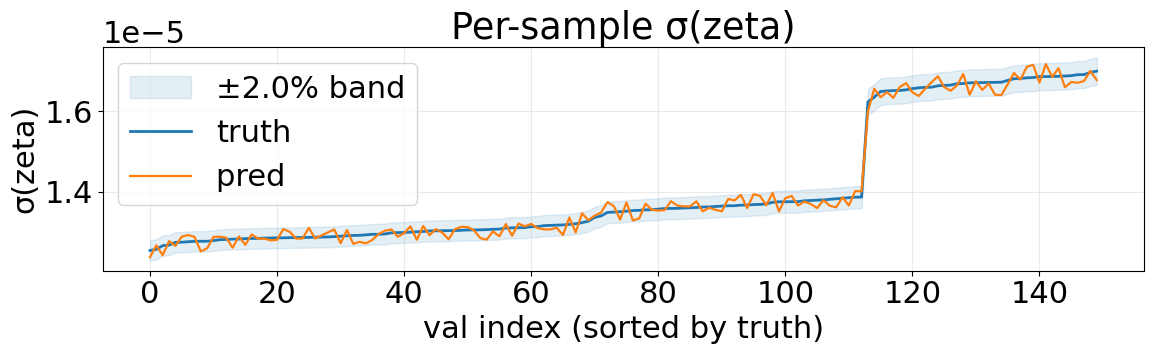

All adjusted points within band: True
k stats: min=0.0845 median=0.979 max=385


(array([1.23687839e-05, 1.26647903e-05, 1.24192862e-05, 1.27674757e-05,
        1.26508250e-05, 1.28804336e-05, 1.29205384e-05, 1.28755943e-05,
        1.25125791e-05, 1.25917960e-05, 1.28737868e-05, 1.28784364e-05,
        1.28540515e-05, 1.26048534e-05, 1.28854226e-05, 1.26754293e-05,
        1.29358458e-05, 1.28298812e-05, 1.28295371e-05, 1.27886136e-05,
        1.28008938e-05, 1.30701877e-05, 1.29997147e-05, 1.28304808e-05,
        1.28335393e-05, 1.30986691e-05, 1.28341961e-05, 1.29099566e-05,
        1.29839905e-05, 1.30613131e-05, 1.27185761e-05, 1.30465869e-05,
        1.27016253e-05, 1.27512793e-05, 1.27143545e-05, 1.27997028e-05,
        1.29479640e-05, 1.30288890e-05, 1.30595754e-05, 1.28777083e-05,
        1.29689334e-05, 1.31354838e-05, 1.28030942e-05, 1.31453858e-05,
        1.29193274e-05, 1.30673199e-05, 1.29815543e-05, 1.28136633e-05,
        1.30678440e-05, 1.31260802e-05, 1.31192311e-05, 1.30368950e-05,
        1.28422258e-05, 1.28068098e-05, 1.30109975e-05, 1.288763

In [50]:
sigma_true_all, sigma_pred_all, _, _ = collect_sigma_centroid_over_val(
    model, 
    val_loader, 
    device,
    mu_prep = mu_prep,
    N_elem=32
)
plt.rcParams.update({'font.size': 22})
# sigma_x with random in-band adjustment
plot_sigma_vs_index_random_band(
    sigma_true_all, sigma_pred_all,
    coord=2,
    eps_percent=2.0,
    mode="loguniform",
    seed=42,
)